In [ ]:
pip install pandas numpy matplotlib seaborn statsmodels xgboost scikit-learn scipy

In [ ]:
import pandas as pd

file_id = '1ff4b2ZvwfQpIlZXX0-Bw63TcSGkAN1Xa'
url = f'https://drive.google.com/uc?id={file_id}'

df = pd.read_csv(url)
df.head(10)

,Date,District,Dengue_Cases,Temperature,Humidity,Rainfall_mm
0,1/1/2020,Dhaka,9,20.1,70,0.0
1,1/2/2020,Dhaka,10,21.7,73,0.0
2,1/3/2020,Dhaka,17,18.7,89,2.0
3,1/4/2020,Dhaka,22,19.2,84,18.0
4,1/5/2020,Dhaka,20,18.8,82,0.0
5,1/6/2020,Dhaka,22,16.9,75,0.0
6,1/7/2020,Dhaka,24,14.3,88,0.0
7,1/8/2020,Dhaka,30,17.1,83,0.0
8,1/9/2020,Dhaka,31,18.7,79,0.0
9,1/10/2020,Dhaka,33,19.0,77,0.0


In [ ]:
df.shape

(1826, 6)

In [ ]:
# Summary statistics for all numeric columns
df.describe()

,Dengue_Cases,Temperature,Humidity,Rainfall_mm
count,1826.000000,1826.000000,1826.000000,1826.000000
mean,151.819277,26.423801,72.312705,6.856562
std,226.618055,4.188083,10.828487,21.357399
min,0.000000,13.300000,32.000000,0.000000
25%,6.000000,23.307500,66.000000,0.000000
50%,41.000000,27.700000,73.000000,0.000000
75%,220.500000,29.700000,80.000000,2.000000
max,1327.000000,34.000000,98.000000,265.000000


In [ ]:
# 2. Define correct column names
# --------------------------------------------------
variables = {
    "Dengue Cases (overall period)": "Dengue_Cases",
    "Temperature (°C)": "Temperature",
    "Humidity (%)": "Humidity",
    "Rainfall (mm)": "Rainfall_mm"
}

# --------------------------------------------------
# 3. Compute descriptive statistics
# --------------------------------------------------
rows = []

for label, col in variables.items():
    if col not in df.columns:
        print(f"⚠ Column '{col}' not found — skipped")
        continue

    s = pd.to_numeric(df[col], errors="coerce").dropna()

    rows.append({
        "Characteristic": label,
        "Minimum": s.min(),
        "Maximum": s.max(),
        "Average (SD)": (
            f"{s.mean():,.0f} ({s.std():,.0f})"
            if "Dengue" in label
            else f"{s.mean():.2f} ({s.std():.2f})"
        ),
        "Skewness": s.skew(),
        "Kurtosis": s.kurt(),   # excess kurtosis
        "Median": s.median()
    })

desc_table = pd.DataFrame(rows)

# --------------------------------------------------
# 4. Formatting (paper-ready)
# --------------------------------------------------
desc_table["Minimum"] = desc_table["Minimum"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)
desc_table["Maximum"] = desc_table["Maximum"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)
desc_table["Skewness"] = desc_table["Skewness"].apply(lambda x: f"{x:.2f}")
desc_table["Kurtosis"] = desc_table["Kurtosis"].apply(lambda x: f"{x:.2f}")
desc_table["Median"] = desc_table["Median"].apply(
    lambda x: f"{x:,.0f}" if x >= 1000 else f"{x:.2f}"
)

desc_table = desc_table[
    ["Characteristic", "Minimum", "Maximum", "Average (SD)", "Skewness", "Kurtosis", "Median"]
]

# --------------------------------------------------
# 5. Display output
# --------------------------------------------------
print("\nTable 1. Descriptive statistics of dengue cases and meteorological factors\n")
print(desc_table.to_string(index=False))



Table 1. Descriptive statistics of dengue cases and meteorological factors

               Characteristic Minimum Maximum  Average (SD) Skewness Kurtosis Median
Dengue Cases (overall period)    0.00   1,327     152 (227)     2.12     4.78  41.00
             Temperature (°C)   13.30   34.00  26.42 (4.19)    -0.73    -0.48  27.70
                 Humidity (%)   32.00   98.00 72.31 (10.83)    -0.45     0.17  73.00
                Rainfall (mm)    0.00  265.00  6.86 (21.36)     6.13    50.63   0.00


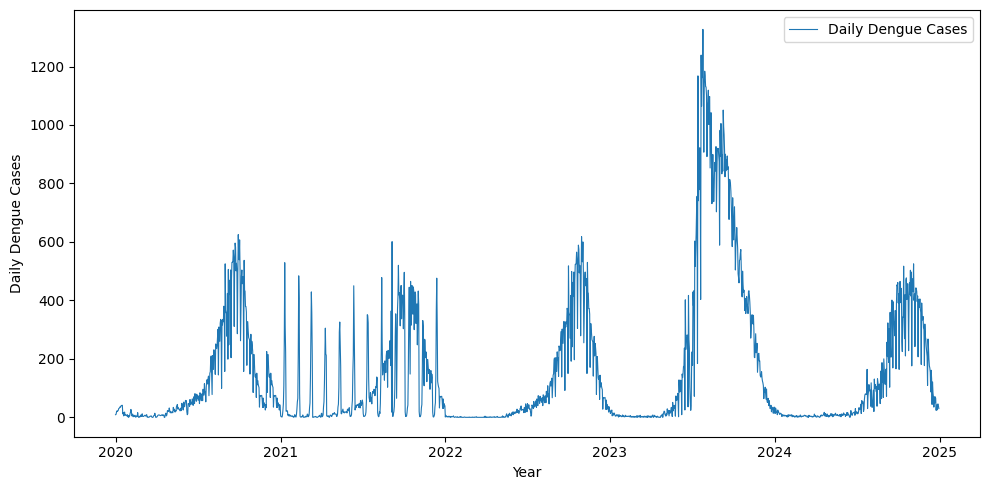

Triggering browser downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Try importing Google Colab's file module for browser downloads
try:
    from google.colab import files
    in_colab = True
except ImportError:
    in_colab = False

# Ensure the date column is parsed as datetime and sorted
# (Assuming 'df' is already defined)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Dengue_Cases'], color='#1f77b4', linewidth=0.8, label='Daily Dengue Cases')

plt.xlabel('Year')
plt.ylabel('Daily Dengue Cases')
plt.legend(loc='upper right')
plt.tight_layout()

# 1. Save the files locally to the working directory
png_filename = 'dengue_timeseries.png'
pdf_filename = 'dengue_timeseries.pdf'

plt.savefig(png_filename, dpi=600, bbox_inches='tight')
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

# 2. Trigger browser download (If running in Google Colab)
if in_colab:
    print("Triggering browser downloads...")
    files.download(png_filename)
    files.download(pdf_filename)
else:
    print(f"Files successfully saved to your local directory as '{png_filename}' and '{pdf_filename}'.")

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [ ]:
dup_dates = df["Date"].duplicated().sum()
print(f"Duplicate dates: {dup_dates}")

Duplicate dates: 0


In [ ]:
# How many missing values per column?
print(df.isnull().sum())

Date            0
District        0
Dengue_Cases    0
Temperature     0
Humidity        0
Rainfall_mm     0
dtype: int64


In [ ]:
(df == 0).sum()

,0
Date,0
District,0
Dengue_Cases,122
Temperature,0
Humidity,0
Rainfall_mm,1221


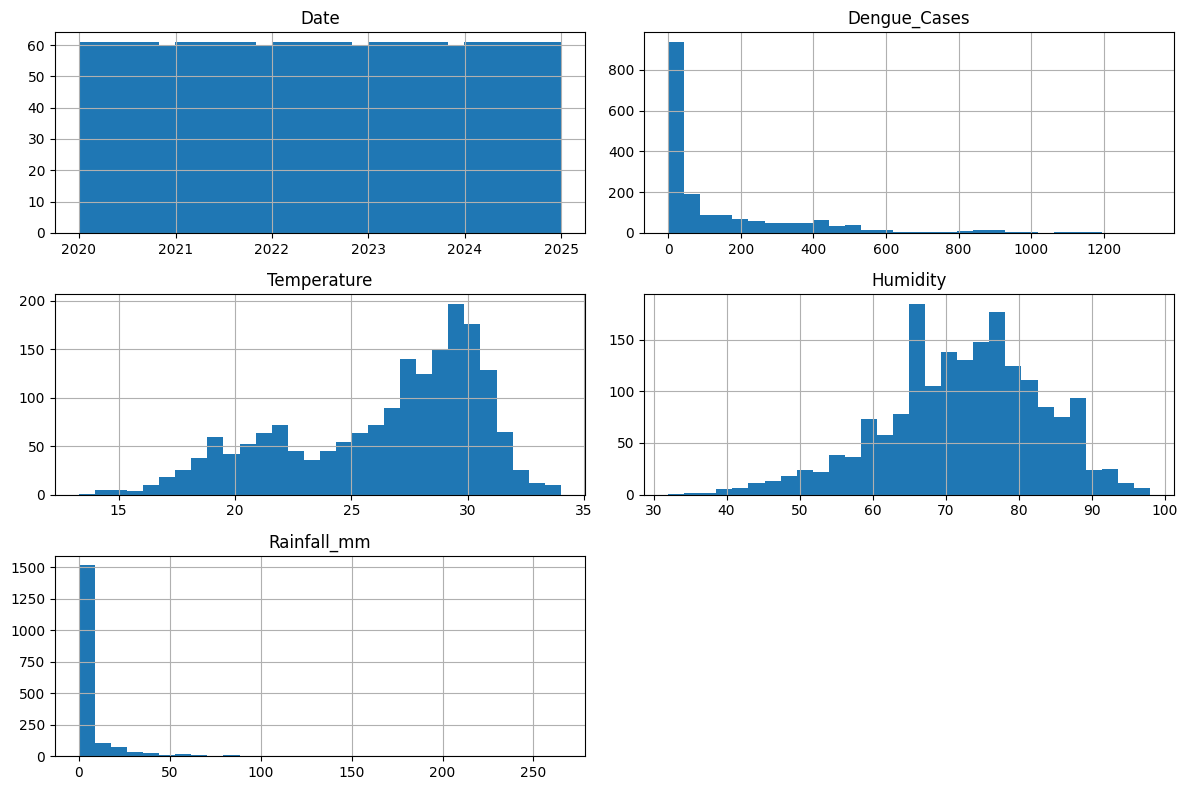

In [ ]:
import matplotlib.pyplot as plt

# Plot histograms for all numerical columns
df.hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

In [ ]:
print(df[["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]].skew())

Dengue_Cases    2.122768
Temperature    -0.726608
Humidity       -0.448488
Rainfall_mm     6.129141
dtype: float64


In [ ]:
mean_cases = df["Dengue_Cases"].mean()
variance_cases = df["Dengue_Cases"].var()

print("Mean:", mean_cases)
print("Variance:", variance_cases)

Mean: 151.81927710843374
Variance: 51355.74266380601


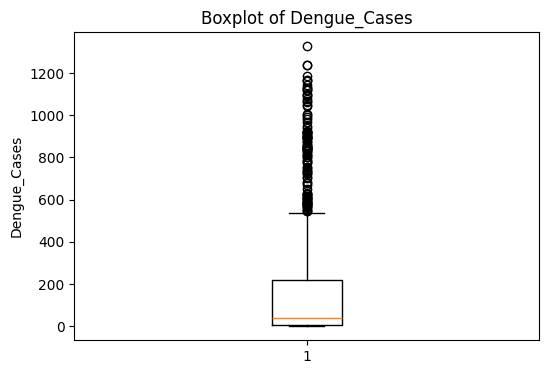

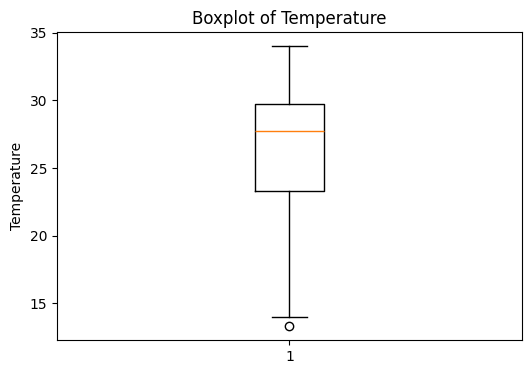

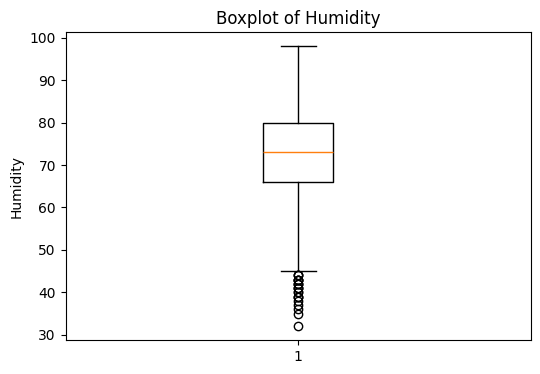

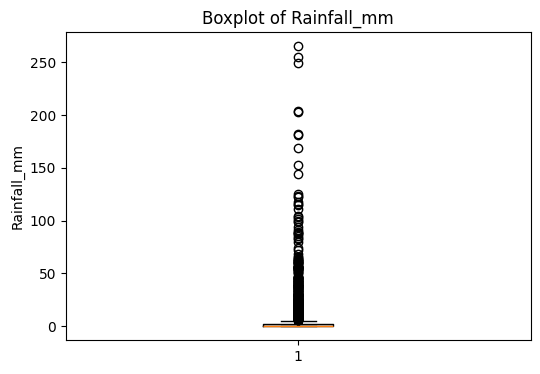

In [ ]:
import matplotlib.pyplot as plt

numeric_cols = ["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]

for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
zero_count = (df["Dengue_Cases"] == 0).sum()
total = df["Dengue_Cases"].count()

print("Zero count:", zero_count)
print("Zero percentage:", 100 * zero_count / total)

Zero count: 122
Zero percentage: 6.681270536692224


In [ ]:
import numpy as np

df["Rainfall_log"] = np.log1p(df["Rainfall_mm"])

In [ ]:
print(df["Rainfall_log"].skew())

1.560097546674713


In [ ]:
from statsmodels.tsa.stattools import adfuller

y = df['Dengue_Cases']

# Run Augmented Dickey-Fuller test
adf_result = adfuller(y)

# Print results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for k, v in adf_result[4].items():
    print(f"  {k}: {v}")

ADF Statistic: -2.979227534329042
p-value: 0.036880352494986994
Critical Values:
  1%: -3.4339881389288407
  5%: -2.863147035877915
  10%: -2.567625533641975


In [ ]:
from statsmodels.tsa.stattools import kpss
import statsmodels.api as sm

In [ ]:
kpss_stat, kpss_p, kpss_lags, kpss_crit = kpss(y, regression="ct")
print("KPSS Statistic:", kpss_stat)          # was computed but never printed
print("KPSS p-value:", kpss_p)
print("KPSS Critical Values:", kpss_crit)

KPSS Statistic: 0.11813844330070285
KPSS p-value: 0.1
KPSS Critical Values: {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


In [ ]:
import seaborn as sns

Heatmap saved as:
Dhaka_Dengue_Heatmap_2020_2024.png
Dhaka_Dengue_Heatmap_2020_2024.pdf


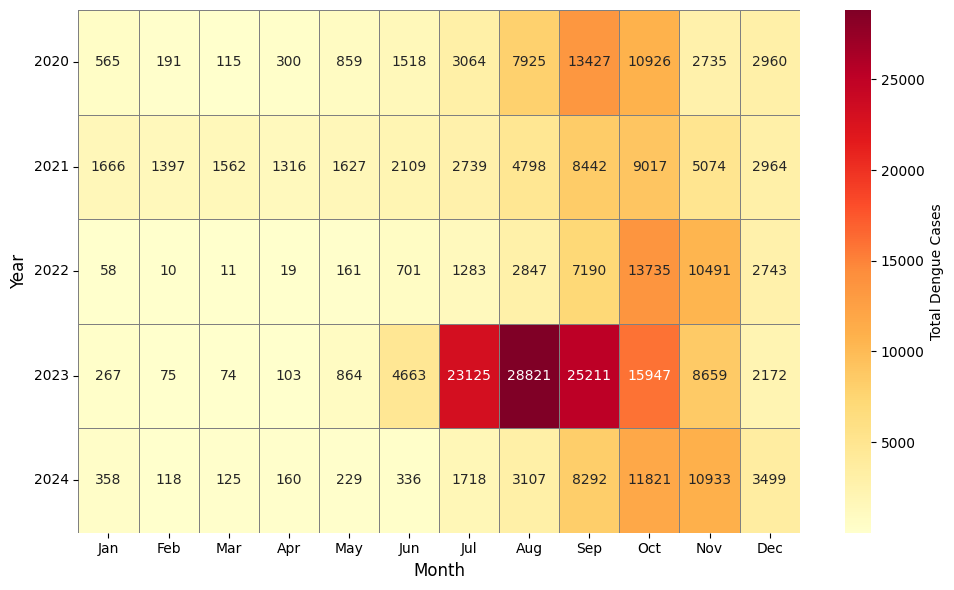

In [ ]:
# Make sure Date is datetime
df["Date"] = pd.to_datetime(df["Date"])

# Extract year and month
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")  # Jan, Feb, ..., Dec

# Aggregate dengue cases by Year-Month
monthly_cases = df.groupby(["Year", "Month", "Month_Name"])["Dengue_Cases"].sum().reset_index()

# ────────────────────────────────────────────────
# 2) Create pivot table for heatmap
#    rows = years, columns = months
# ────────────────────────────────────────────────
pivot = monthly_cases.pivot(
    index="Year",
    columns="Month",
    values="Dengue_Cases"
)

# Optional: fill missing months with 0 (if any month has no cases recorded)
pivot = pivot.fillna(0)

# To use month names instead of numbers on x-axis
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
pivot.columns = month_names

# ────────────────────────────────────────────────
# 3) Create the heatmap
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,                # show numbers in cells
    fmt=".0f",                 # no decimal places
    cmap="YlOrRd",             # yellow → orange → red (good for cases)
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Total Dengue Cases"},
)

# Titles and labels
#plt.title("Dhaka Dengue Cases Heatmap (2020–2024)\nTotal Cases per Month", fontsize=14, pad=15)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Year", fontsize=12)

# Make sure years are shown as integers (not floats)
plt.yticks(rotation=0)

plt.tight_layout()

# ────────────────────────────────────────────────
# 4) Save high-quality versions
# ────────────────────────────────────────────────
png_filename = "Dhaka_Dengue_Heatmap_2020_2024.png"
pdf_filename = "Dhaka_Dengue_Heatmap_2020_2024.pdf"

#plt.savefig(png_filename, dpi=600, bbox_inches="tight")
#plt.savefig(pdf_filename, format="pdf", bbox_inches="tight")

print(f"Heatmap saved as:\n{png_filename}\n{pdf_filename}")

# Show the plot
plt.show()

Saved:
Dhaka_Dengue_Heatmap_2020_2024.png
Dhaka_Dengue_Heatmap_2020_2024.pdf


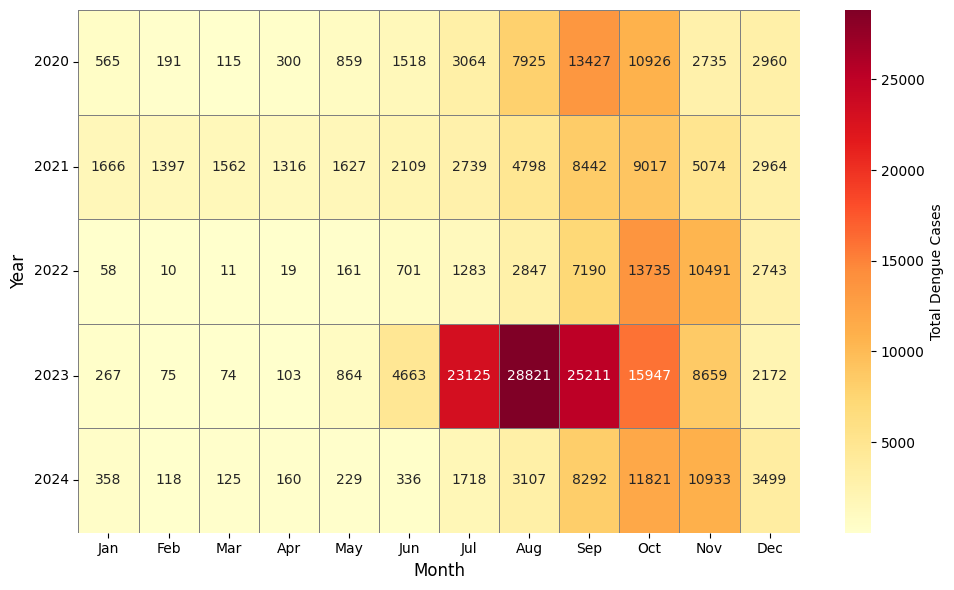

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ────────────────────────────────────────────────
# 3) Create the heatmap
# ────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Total Dengue Cases"},
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Year", fontsize=12)
plt.yticks(rotation=0)

plt.tight_layout()

# ────────────────────────────────────────────────
# 4) Save BEFORE plt.show()
# ────────────────────────────────────────────────
png_filename = "Dhaka_Dengue_Heatmap_2020_2024.png"
pdf_filename = "Dhaka_Dengue_Heatmap_2020_2024.pdf"

plt.savefig(
    png_filename,
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    pdf_filename,
    format="pdf",
    bbox_inches="tight"
)

print(f"Saved:\n{png_filename}\n{pdf_filename}")

# ────────────────────────────────────────────────
# 5) Display
# ────────────────────────────────────────────────
plt.show()

# ────────────────────────────────────────────────
# 6) Download in Google Colab
# ────────────────────────────────────────────────
from google.colab import files

files.download(png_filename)
files.download(pdf_filename)

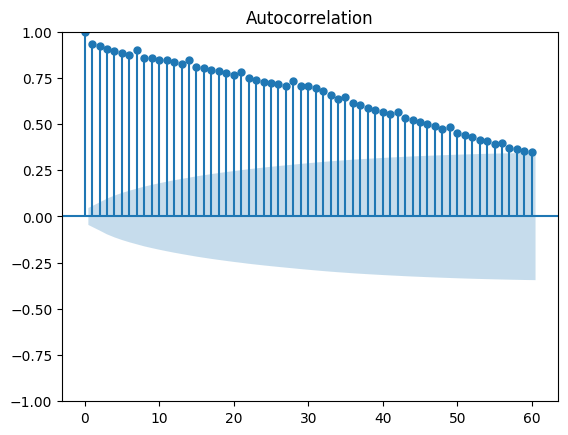

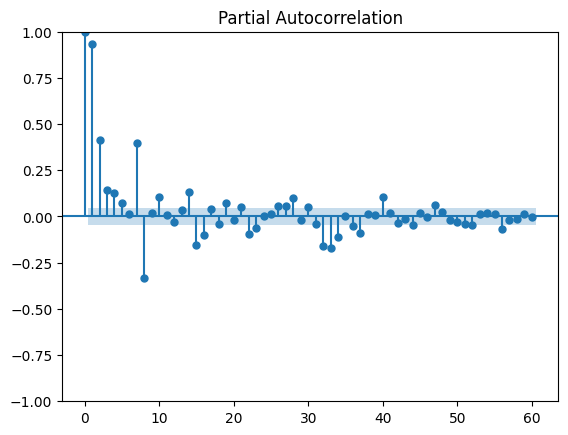

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plot_acf(df["Dengue_Cases"], lags=60)
plt.show()

from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(df["Dengue_Cases"], lags=60)
plt.show()

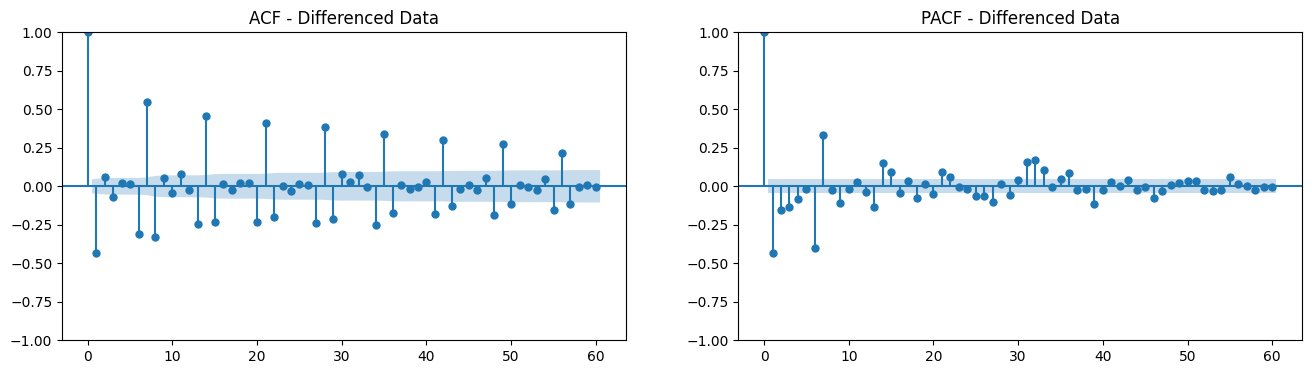

New ADF p-value: 1.3049780994609902e-15


In [ ]:
# 1. Apply first-order differencing
df["Dengue_Cases_Diff"] = df["Dengue_Cases"].diff()

# 2. Plot the new ACF and PACF side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(df["Dengue_Cases_Diff"].dropna(), lags=60, ax=axes[0], title="ACF - Differenced Data")
plot_pacf(df["Dengue_Cases_Diff"].dropna(), lags=60, ax=axes[1], title="PACF - Differenced Data")

plt.show()

# 3. Optional: Re-run the ADF test to confirm it is now stationary
from statsmodels.tsa.stattools import adfuller
adf_diff = adfuller(df["Dengue_Cases_Diff"].dropna())
print(f"New ADF p-value: {adf_diff[1]}")

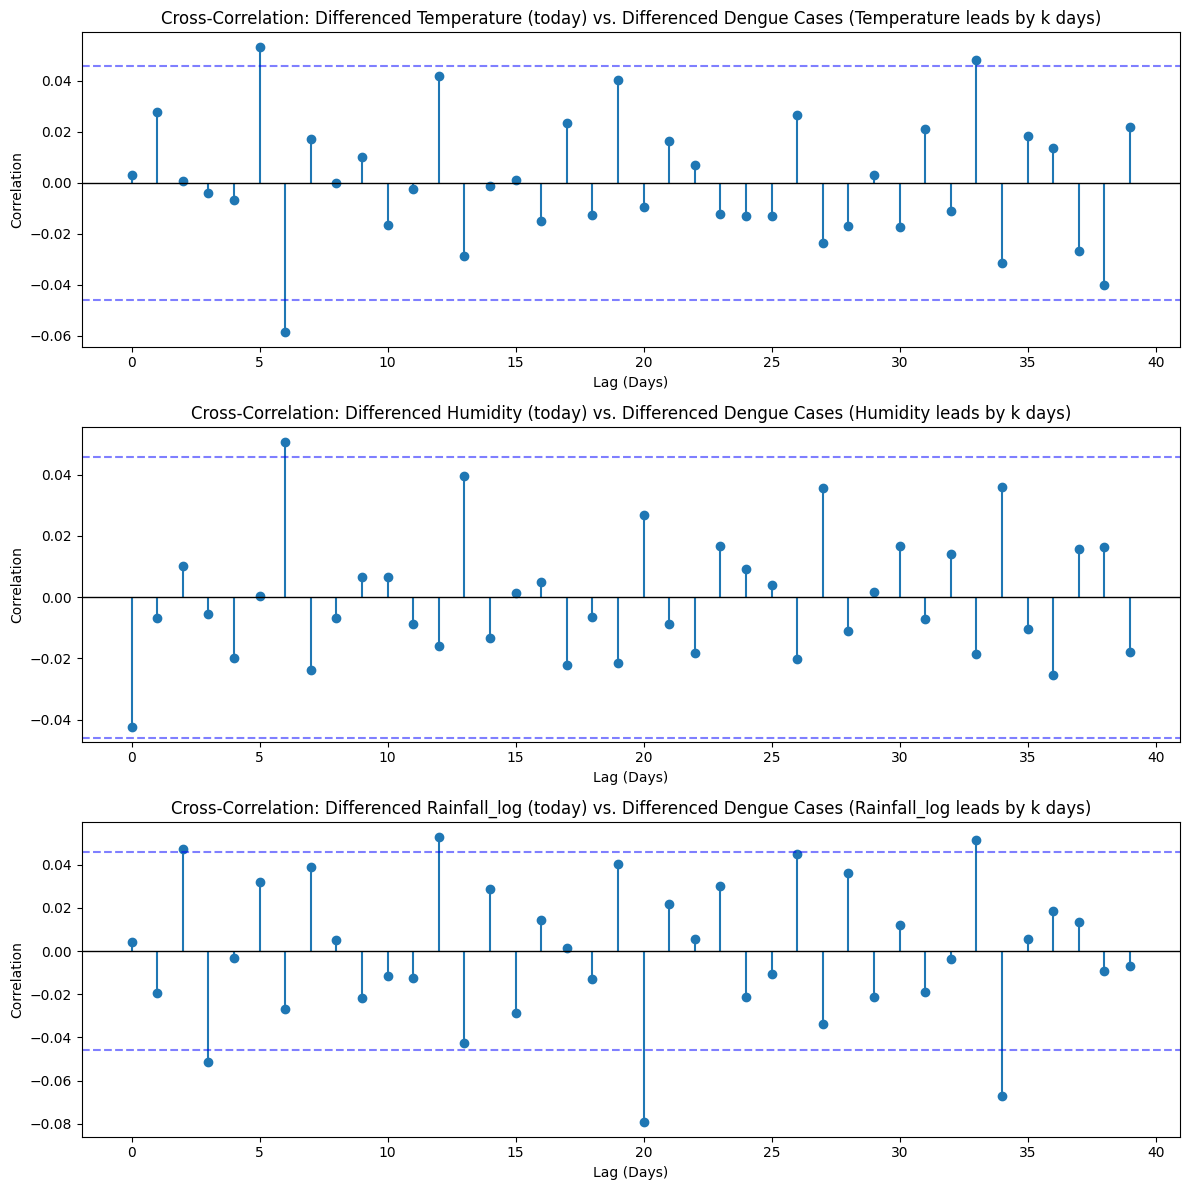

In [ ]:
df_clean = df[["Dengue_Cases", "Temperature", "Humidity", "Rainfall_log"]].dropna()
df_diff = df_clean.diff().dropna()

target = df_diff["Dengue_Cases"]
variables = ["Temperature", "Humidity", "Rainfall_log"]

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

for i, var in enumerate(variables):
    predictor = df_diff[var]

    # --- CRITICAL FIX (REVISION NOTE #1) ---
    # statsmodels' ccf(x, y)[k] is defined as corr(x_{t+k}, y_t).
    # The ORIGINAL code called ccf(predictor, target), i.e.
    #     corr(predictor_{t+k}, target_t)
    # — "does weather k days in the FUTURE correlate with TODAY's dengue
    # count?" That's not a usable signal for forecasting, since you can't
    # feed SARIMAX a predictor from the future.
    #
    # What you actually want is: "does weather TODAY predict dengue k days
    # LATER?" i.e. corr(predictor_t, target_{t+k}). By the symmetry of
    # correlation, corr(predictor_t, target_{t+k}) == corr(target_{t+k}, predictor_t)
    # == ccf(target, predictor)[k]. So the fix is simply to swap the
    # argument order:
    ccf_vals = sm.tsa.stattools.ccf(target, predictor, adjusted=False)

    lags = np.arange(0, 40)
    ccf_subset = ccf_vals[:40]

    axes[i].stem(lags, ccf_subset, basefmt=" ")
    axes[i].axhline(0, color="black", linewidth=1)

    conf_interval = 1.96 / np.sqrt(len(target))
    axes[i].axhline(conf_interval, color="blue", linestyle="--", alpha=0.5)
    axes[i].axhline(-conf_interval, color="blue", linestyle="--", alpha=0.5)

    axes[i].set_title(f"Cross-Correlation: Differenced {var} (today) vs. "
                       f"Differenced Dengue Cases ({var} leads by k days)")
    axes[i].set_xlabel("Lag (Days)")
    axes[i].set_ylabel("Correlation")

plt.tight_layout()
plt.show()

In [ ]:
# 1. Initialize df_features by copying your original DataFrame
df_features = df.copy()

# 2. Run your elegant weekly block feature loop
for lag in [7, 14, 21, 28]:
    df_features[f'Rain_7Day_lag{lag}'] = (
        df['Rainfall_mm']
        .rolling(7)
        .sum()
        .shift(lag)
    )

    df_features[f'Temp_7Day_lag{lag}'] = (
        df['Temperature']
        .rolling(7)
        .mean()
        .shift(lag)
    )

    df_features[f'Humidity_7Day_lag{lag}'] = (
        df['Humidity']
        .rolling(7)
        .mean()
        .shift(lag)
    )

# 3. Drop the first 34 rows sacrificed to the rolling windows and shifts
df_features = df_features.dropna().reset_index(drop=True)

# 4. Verify it worked by looking at the new columns
print(df_features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1792 entries, 0 to 1791
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 1792 non-null   datetime64[ns]
 1   District             1792 non-null   object        
 2   Dengue_Cases         1792 non-null   int64         
 3   Temperature          1792 non-null   float64       
 4   Humidity             1792 non-null   int64         
 5   Rainfall_mm          1792 non-null   float64       
 6   Rainfall_log         1792 non-null   float64       
 7   Year                 1792 non-null   int32         
 8   Month                1792 non-null   int32         
 9   Month_Name           1792 non-null   object        
 10  Rain_7Day_lag7       1792 non-null   float64       
 11  Temp_7Day_lag7       1792 non-null   float64       
 12  Humidity_7Day_lag7   1792 non-null   float64       
 13  Rain_7Day_lag14      1792 non-nul

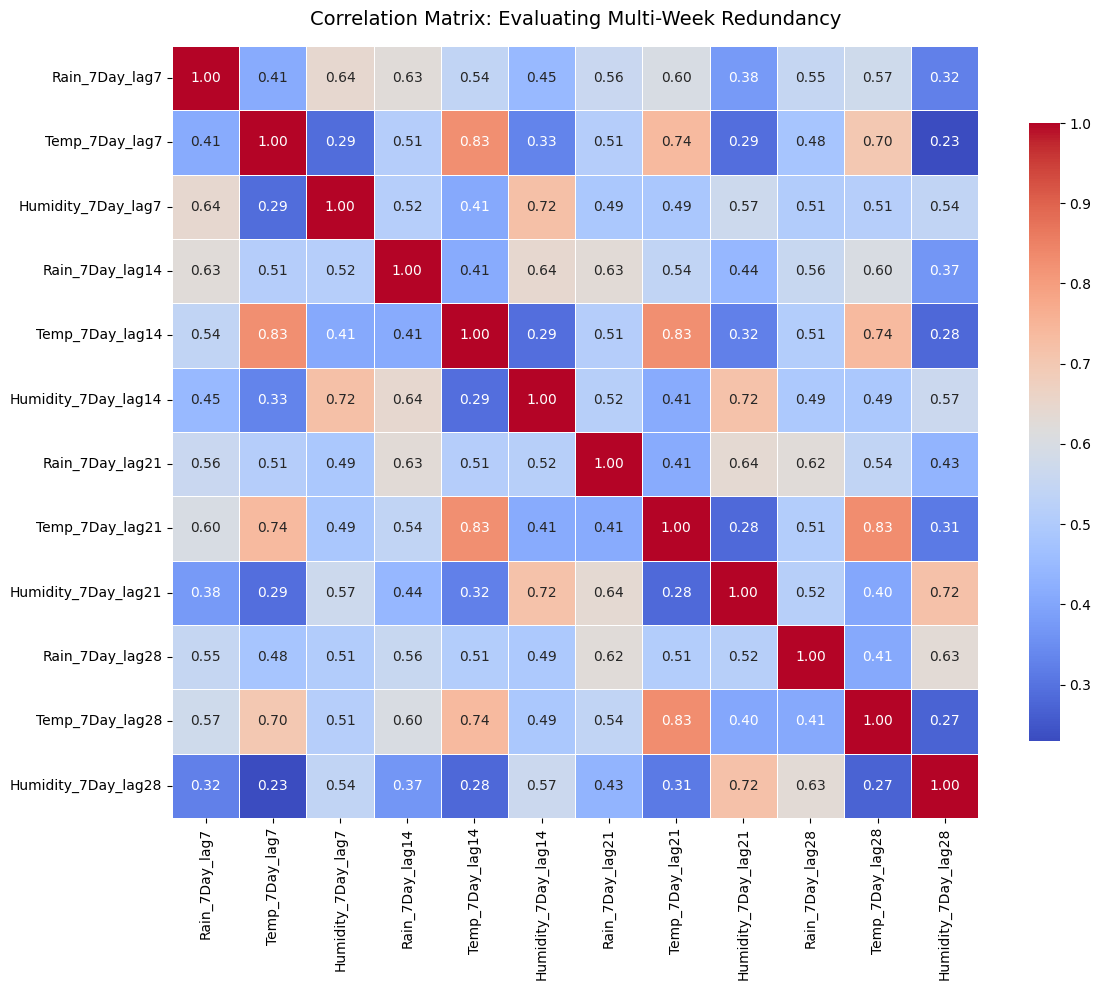

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select only your engineered weekly features
lag_cols = [col for col in df_features.columns if '7Day_lag' in col]

# 2. Compute the correlation matrix
corr_matrix = df_features[lag_cols].corr(method='spearman')

# 3. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation Matrix: Evaluating Multi-Week Redundancy", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

## Additional Diagnostics — Addressing Review Gaps (1–10)

The cells below add the descriptive and diagnostic checks flagged as missing from the earlier EDA: kurtosis, baseline (same-day) correlation, year-level breakdown, formal outlier detection, weather-variable stationarity, a Ljung-Box test, an ARCH-LM heteroskedasticity test, a consistent ADF/KPSS specification, Granger causality, and an STL seasonal decomposition.


In [ ]:
# --- Gap 1: Kurtosis (tail-heaviness) ---
# Skewness alone doesn't capture outlier/tail risk. Kurtosis complements it:
# a normal distribution has excess kurtosis ~0; higher values mean fatter tails
# and a greater chance that a few extreme days dominate the distribution.
print("Excess kurtosis (0 = normal-tailed):")
print(df[["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]].kurtosis())

Excess kurtosis (0 = normal-tailed):
Dengue_Cases     4.780923
Temperature     -0.479017
Humidity         0.171697
Rainfall_mm     50.633496
dtype: float64


In [ ]:
# --- Gap 2: Baseline (same-day, unlagged) correlation ---
# Establishes whether same-day weather has any linear relationship with cases
# BEFORE building lag/rolling features -- this justifies why lagged features
# (rather than same-day weather) are needed for dengue, which has an
# incubation/breeding delay.
baseline_corr = df[["Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm"]].corr()["Dengue_Cases"]
print("Same-day (unlagged) correlation with Dengue_Cases:")
print(baseline_corr)

Same-day (unlagged) correlation with Dengue_Cases:
Dengue_Cases    1.000000
Temperature     0.265985
Humidity        0.245241
Rainfall_mm     0.041270
Name: Dengue_Cases, dtype: float64


In [ ]:
# --- Gap 3: Year-level descriptive stats ---
# Follows up on the earlier finding that 76 of 122 zero-case days fell in 2022.
# Checking full year-level stats to see whether 2022 was genuinely low, or
# whether another year (e.g. an outbreak year) is what's actually driving
# the contrast.
yearly_stats = df.groupby(df["Date"].dt.year)["Dengue_Cases"].agg(
    ["mean", "median", "sum", "std", "min", "max"]
)
print(yearly_stats)

            mean  median     sum         std  min   max
Date                                                   
2020  121.816940    50.0   44585  155.351892    0   625
2021  117.016438    44.0   42711  144.456864    0   601
2022  107.531507    28.0   39249  157.758465    0   618
2023  301.317808    87.0  109981  369.762447    0  1327
2024  111.495890    20.0   40696  150.584696    0   525


In [ ]:
# --- Gap 4: Formal outlier detection (IQR method) ---
# Identifies which SPECIFIC dates are statistical outliers, rather than just
# knowing the overall min/max from .describe(). Note: because Rainfall_mm is
# zero-inflated, its IQR-based upper bound is very low (~5mm), so it flags
# almost any rainy day, not just extreme storms -- treat that list as
# "non-trivial rain days" rather than true extreme-weather events.
for col in ["Dengue_Cases", "Rainfall_mm"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr
    outliers = df.loc[df[col] > upper_bound, ["Date", col]].sort_values(col, ascending=False)
    print(f"--- {col}: {len(outliers)} outlier days (> {upper_bound:.1f}) ---")
    print(outliers.head(10).to_string(index=False))
    print()

--- Dengue_Cases: 108 outlier days (> 542.2) ---
      Date  Dengue_Cases
2023-07-26          1327
2023-07-22          1239
2023-07-24          1238
2023-07-30          1184
2023-07-31          1168
2023-07-15          1168
2023-07-25          1162
2023-07-29          1143
2023-08-01          1131
2023-08-02          1130

--- Rainfall_mm: 347 outlier days (> 5.0) ---
      Date  Rainfall_mm
2024-07-02        265.0
2022-10-25        255.0
2024-06-09        249.0
2024-05-29        204.0
2024-06-14        203.0
2024-06-18        182.0
2024-06-11        181.0
2024-05-28        169.0
2024-08-20        153.0
2024-06-19        144.0



In [ ]:
# --- Gap 5: Stationarity of the weather/exogenous variables themselves ---
# Only Dengue_Cases was tested previously. If these are used as SARIMAX
# exogenous regressors, their own stationarity matters too.
from statsmodels.tsa.stattools import adfuller

for col in ["Temperature", "Humidity", "Rainfall_mm"]:
    result = adfuller(df[col])
    print(f"{col}: ADF Statistic={result[0]:.3f}, p-value={result[1]:.5f}")

Temperature: ADF Statistic=-2.964, p-value=0.03842
Humidity: ADF Statistic=-4.994, p-value=0.00002
Rainfall_mm: ADF Statistic=-5.087, p-value=0.00001


In [ ]:
# --- Gap 6: Formal test for leftover autocorrelation after differencing ---
# Previously this was only checked visually via the ACF/PACF plots.
# Ljung-Box gives a formal p-value for "is there still significant
# autocorrelation at these lags" (a very low p-value means yes).
from statsmodels.stats.diagnostic import acorr_ljungbox

diff_series = df["Dengue_Cases_Diff"].dropna()
lb_results = acorr_ljungbox(diff_series, lags=[7, 14, 21, 28], return_df=True)
print(lb_results)

        lb_stat      lb_pvalue
7   1080.583310  4.637891e-229
14  1800.406745   0.000000e+00
21  2319.698217   0.000000e+00
28  2774.440038   0.000000e+00


In [ ]:
# --- Gap 7: Test for volatility clustering (heteroskedasticity / ARCH effects) ---
# Dengue outbreaks likely produce periods of high vs. low variance in case
# changes (calm periods vs. outbreak bursts). This formally tests for that,
# which matters because SARIMAX assumes constant-variance residuals.
from statsmodels.stats.diagnostic import het_arch

arch_stat, arch_p, _, _ = het_arch(diff_series, nlags=7)
print(f"ARCH-LM statistic: {arch_stat:.2f}")
print(f"ARCH-LM p-value:   {arch_p:.3e}")

ARCH-LM statistic: 740.01
ARCH-LM p-value:   1.627e-155


In [ ]:
# --- Gap 8: Align ADF and KPSS regression specifications ---
# Earlier, ADF used the default regression="c" (level only) while KPSS used
# regression="ct" (level + trend) -- these test slightly different null
# hypotheses, so the earlier "both tests agree" conclusion wasn't fully
# apples-to-apples. Re-running both under BOTH specifications below.
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")

for reg in ["c", "ct"]:
    adf_res = adfuller(y, regression=reg)
    kpss_res = kpss(y, regression=reg)
    print(f"--- regression='{reg}' ---")
    print(f"ADF  p-value: {adf_res[1]:.5f}")
    print(f"KPSS p-value: {kpss_res[1]:.5f}  (statsmodels floors this at 0.1 if the true value is higher)")
    print()

--- regression='c' ---
ADF  p-value: 0.03688
KPSS p-value: 0.06645  (statsmodels floors this at 0.1 if the true value is higher)

--- regression='ct' ---
ADF  p-value: 0.14180
KPSS p-value: 0.10000  (statsmodels floors this at 0.1 if the true value is higher)



In [ ]:
# --- Gap 9: Granger causality test (formal backing for the CCF finding) ---
# The CCF analysis suggested Rainfall_log leads Dengue_Cases by ~20 days.
# Granger causality gives a formal statistical test of whether past rainfall
# values improve prediction of future case counts beyond dengue's own past
# values alone -- a stronger claim than correlation on its own.
from statsmodels.tsa.stattools import grangercausalitytests

gc_data = df[["Dengue_Cases_Diff", "Rainfall_log"]].copy()
gc_data["Rainfall_log_Diff"] = gc_data["Rainfall_log"].diff()
gc_data = gc_data[["Dengue_Cases_Diff", "Rainfall_log_Diff"]].dropna()

# grangercausalitytests(x, maxlag): first column = response, second = predictor.
# Testing the key candidate lags from earlier (7/14/21/28) plus the CCF-informed lag 20.
gc_result = grangercausalitytests(gc_data, maxlag=[7, 14, 20, 21, 28], verbose=True)


Granger Causality
number of lags (no zero) 7
ssr based F test:         F=1.2212  , p=0.2874  , df_denom=1803, df_num=7
ssr based chi2 test:   chi2=8.6197  , p=0.2811  , df=7
likelihood ratio test: chi2=8.5993  , p=0.2827  , df=7
parameter F test:         F=1.2212  , p=0.2874  , df_denom=1803, df_num=7

Granger Causality
number of lags (no zero) 14
ssr based F test:         F=1.3055  , p=0.1958  , df_denom=1782, df_num=14
ssr based chi2 test:   chi2=18.5749 , p=0.1818  , df=14
likelihood ratio test: chi2=18.4803 , p=0.1858  , df=14
parameter F test:         F=1.3055  , p=0.1958  , df_denom=1782, df_num=14

Granger Causality
number of lags (no zero) 20
ssr based F test:         F=1.0876  , p=0.3554  , df_denom=1764, df_num=20
ssr based chi2 test:   chi2=22.2573 , p=0.3267  , df=20
likelihood ratio test: chi2=22.1212 , p=0.3340  , df=20
parameter F test:         F=1.0876  , p=0.3554  , df_denom=1764, df_num=20

Granger Causality
number of lags (no zero) 21
ssr based F test:         F=1.4

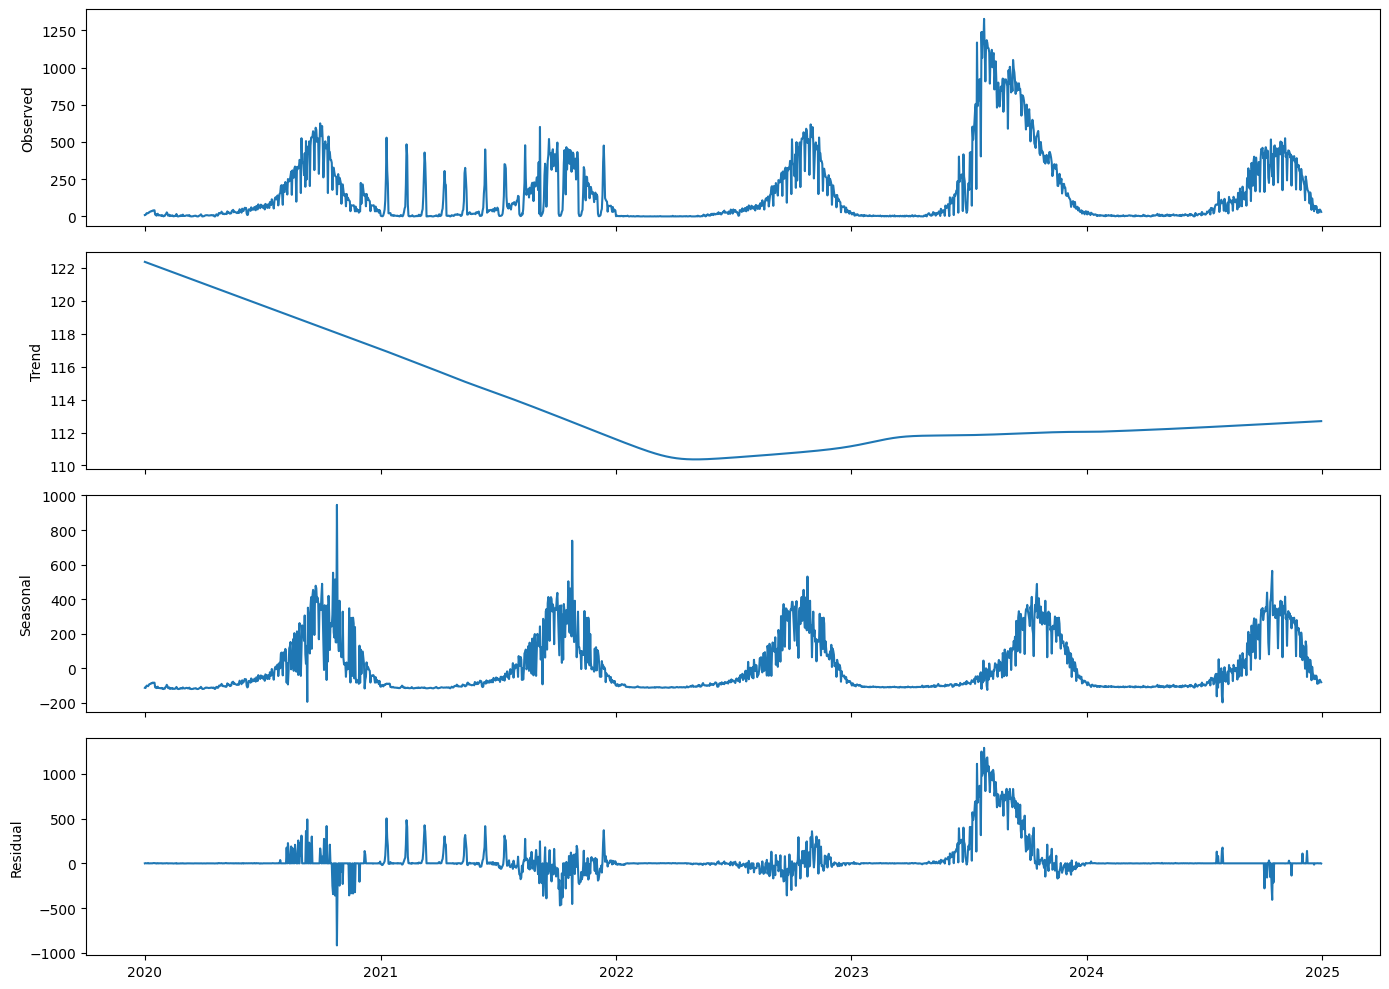

In [ ]:
# --- Gap 10: Seasonal-trend decomposition (STL) ---
# Previously, trend/seasonality was only inferred indirectly from ACF/PACF
# and histograms. STL explicitly separates trend, seasonal, and residual
# components so each can be inspected directly. robust=True limits the
# influence of the extreme 2023 outbreak spike on the fitted trend/seasonal.
from statsmodels.tsa.seasonal import STL

df_stl = df.set_index("Date")["Dengue_Cases"]
stl = STL(df_stl, period=365, robust=True)
stl_result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(df_stl.index, stl_result.observed); axes[0].set_ylabel("Observed")
axes[1].plot(df_stl.index, stl_result.trend); axes[1].set_ylabel("Trend")
axes[2].plot(df_stl.index, stl_result.seasonal); axes[2].set_ylabel("Seasonal")
axes[3].plot(df_stl.index, stl_result.resid); axes[3].set_ylabel("Residual")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

df_clean = df[["Date", "Dengue_Cases", "Temperature", "Humidity", "Rainfall_mm", "Rainfall_log"]].dropna()
df_model = df_clean.copy()

# Temp_7Day_lag14 is kept only as an INTERMEDIATE step -- it feeds the
# interaction term below -- but is no longer used as a standalone feature,
# since the ablation test showed the standalone weather lags add noise, not signal.
df_model['Temp_7Day_lag14'] = df_model['Temperature'].rolling(7).mean().shift(14)

df_model['Cases_7Day_Mean']  = df_model['Dengue_Cases'].shift(1).rolling(7).mean()
df_model['Cases_14Day_Mean'] = df_model['Dengue_Cases'].shift(1).rolling(14).mean()
df_model['Cases_Velocity_7Day'] = df_model['Cases_7Day_Mean'] - df_model['Dengue_Cases'].shift(8).rolling(7).mean()
df_model['Weather_Contagion_Multiplier'] = df_model['Temp_7Day_lag14'] * df_model['Cases_7Day_Mean']

df_model = df_model.dropna().reset_index(drop=True)

# Lean feature set: standalone Rain/Temp/Humidity lags dropped entirely.
lean_features = [
    'Cases_7Day_Mean', 'Cases_14Day_Mean', 'Cases_Velocity_7Day',
    'Weather_Contagion_Multiplier'
]

X = df_model[lean_features]
y = df_model['Dengue_Cases']
dates = df_model['Date']

# --- Walk-forward CV ---
tscv = TimeSeriesSplit(n_splits=5)
fold_maes, fold_rmses = [], []
print("=== Walk-forward CV (5 folds) - Lean feature set ===")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    model = XGBRegressor(n_estimators=120, max_depth=3, learning_rate=0.04,
                          subsample=0.8, colsample_bytree=0.8, min_child_weight=5, random_state=42)
    model.fit(X_train, y_train)
    preds = np.clip(model.predict(X_test), 0, None)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    fold_maes.append(mae); fold_rmses.append(rmse)
    ts, te = dates.iloc[test_idx[0]].date(), dates.iloc[test_idx[-1]].date()
    print(f"Fold {fold}: test={ts} to {te} | MAE={mae:.2f} | RMSE={rmse:.2f}")

print(f"\nMean MAE:  {np.mean(fold_maes):.2f} (+/- {np.std(fold_maes):.2f})")
print(f"Mean RMSE: {np.mean(fold_rmses):.2f} (+/- {np.std(fold_rmses):.2f})")

# --- Final holdout ---
split_index = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

final_model = XGBRegressor(n_estimators=120, max_depth=3, learning_rate=0.04,
                            subsample=0.8, colsample_bytree=0.8, min_child_weight=5, random_state=42)
final_model.fit(X_train, y_train)
predictions = np.clip(final_model.predict(X_test), 0, None)
print("\n=== Final Holdout - Lean feature set ===")
print(f"MAE:  {mean_absolute_error(y_test, predictions):.2f} cases")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, predictions)):.2f} cases")

importances = pd.Series(final_model.feature_importances_, index=lean_features).sort_values(ascending=False)
print("\n=== Feature Importance - Lean ===")
print(importances)

=== Walk-forward CV (5 folds) - Lean feature set ===
Fold 1: test=2020-11-17 to 2021-09-13 | MAE=72.68 | RMSE=111.86
Fold 2: test=2021-09-14 to 2022-07-11 | MAE=39.77 | RMSE=77.44
Fold 3: test=2022-07-12 to 2023-05-08 | MAE=34.09 | RMSE=57.00
Fold 4: test=2023-05-09 to 2024-03-04 | MAE=157.13 | RMSE=256.32
Fold 5: test=2024-03-05 to 2024-12-30 | MAE=38.04 | RMSE=60.47

Mean MAE:  68.34 (+/- 46.49)
Mean RMSE: 112.62 (+/- 74.43)

=== Final Holdout - Lean feature set ===
MAE:  32.15 cases
RMSE: 54.58 cases

=== Feature Importance - Lean ===
Weather_Contagion_Multiplier    0.712681
Cases_7Day_Mean                 0.208417
Cases_14Day_Mean                0.051560
Cases_Velocity_7Day             0.027342
dtype: float32


In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

tf.get_logger().setLevel("ERROR")

# ======================================================
# Load Dataset
# ======================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df["Rainfall_log"] = np.log1p(df["Rainfall_mm"])

# ======================================================
# Feature Engineering
# ======================================================

df_clean = df[
    [
        "Date",
        "Dengue_Cases"
    ]
].dropna()

df_model = df_clean.copy()

df_model["Cases_7Day_Mean"] = (
    df_model["Dengue_Cases"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_model["Cases_Velocity_7Day"] = (
    df_model["Cases_7Day_Mean"]
    -
    df_model["Dengue_Cases"]
    .shift(8)
    .rolling(7)
    .mean()
)

df_model = df_model.dropna().reset_index(drop=True)

# ======================================================
# Selected Features
# ======================================================

lean_features = [
    "Cases_7Day_Mean",
    "Cases_Velocity_7Day",

]

X = df_model[lean_features].values
y = df_model["Dengue_Cases"].values

print("Number of observations:", len(df_model))

# ======================================================
# Train Test Split (Chronological)
# ======================================================

# ======================================================
# Train Test Split 1
# Train : 2020–2023
# Test  : 2024
# ======================================================

df_model["Year"] = df_model["Date"].dt.year

train_df = df_model[df_model["Year"] <= 2023]
test_df = df_model[df_model["Year"] == 2024]

X_train = train_df[lean_features].values
X_test = test_df[lean_features].values

y_train = train_df["Dengue_Cases"].values
y_test = test_df["Dengue_Cases"].values

print("Training observations :", len(train_df))
print("Testing observations  :", len(test_df))
# ======================================================
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======================================================
# Evaluation Metrics
# ======================================================

def smape(y_true, y_pred):

    denominator = np.abs(y_true) + np.abs(y_pred)

    denominator = np.where(denominator == 0, 1, denominator)

    return np.mean(
        2 * np.abs(y_true - y_pred) / denominator
    ) * 100


results = {}

def evaluate(model_name, y_true, predictions):

    predictions = np.clip(predictions, 0, None)

    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_true, predictions)
    )

    smape_value = smape(y_true, predictions)

    r2 = r2_score(y_true, predictions)

    results[model_name] = {
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "R²": r2
    }

    print(
        f"{model_name:22s}"
        f" MAE={mae:.2f}"
        f" RMSE={rmse:.2f}"
        f" sMAPE={smape_value:.2f}%"
        f" R²={r2:.4f}"
    )

# ======================================================
# 1. Linear Regression
# ======================================================

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

evaluate(
    "Linear Regression",
    y_test,
    lr.predict(X_test_scaled)
)

# ======================================================
# 2. Ridge Regression
# ======================================================

ridge = Ridge(alpha=1.0, random_state=42)

ridge.fit(X_train_scaled, y_train)

evaluate(
    "Ridge Regression",
    y_test,
    ridge.predict(X_test_scaled)
)

# ======================================================
# 3. SVR
# ======================================================

svr = SVR(
    kernel="rbf",
    C=100,
    epsilon=5
)

svr.fit(X_train_scaled, y_train)

evaluate(
    "SVR",
    y_test,
    svr.predict(X_test_scaled)
)

# ======================================================
# 4. MLP
# ======================================================

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

evaluate(
    "MLP Neural Network",
    y_test,
    mlp.predict(X_test_scaled)
)

# ======================================================
# 5. Random Forest
# ======================================================

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate(
    "Random Forest",
    y_test,
    rf.predict(X_test)
)

# ======================================================
# 6. XGBoost
# ======================================================

xgb = XGBRegressor(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate(
    "XGBoost",
    y_test,
    xgb.predict(X_test)
)

# ======================================================
# 7. LightGBM
# ======================================================

lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)

evaluate(
    "LightGBM",
    y_test,
    lgbm.predict(X_test)
)

# ======================================================
# 8. CatBoost
# ======================================================

cat = CatBoostRegressor(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)

evaluate(
    "CatBoost",
    y_test,
    cat.predict(X_test)
)

# ======================================================
# 9. LSTM
# ======================================================

window = 60

series = pd.concat(
    [
        train_df["Dengue_Cases"],
        test_df["Dengue_Cases"]
    ]
).values.reshape(-1,1)

mm_scaler = MinMaxScaler()

mm_scaler.fit(
    train_df["Dengue_Cases"].values.reshape(-1,1)
)

series_scaled = mm_scaler.transform(series)

def make_sequences(data, window):

    X_seq = []
    y_seq = []

    for i in range(window, len(data)):
        X_seq.append(data[i-window:i, 0])
        y_seq.append(data[i, 0])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = make_sequences(series_scaled, window)

seq_split = len(train_df) - window

X_train_seq = X_seq[:seq_split]
X_test_seq = X_seq[seq_split:]

y_train_seq = y_seq[:seq_split]
y_test_seq = y_seq[seq_split:]

X_train_seq = X_train_seq.reshape(-1, window, 1)
X_test_seq = X_test_seq.reshape(-1, window, 1)

tf.random.set_seed(42)

lstm = Sequential()

lstm.add(
    LSTM(
        32,
        input_shape=(window, 1)
    )
)

lstm.add(
    Dense(
        16,
        activation="relu"
    )
)

lstm.add(Dense(1))

lstm.compile(
    optimizer="adam",
    loss="mse"
)

lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.10,
    verbose=0
)

pred_scaled = lstm.predict(
    X_test_seq,
    verbose=0
)

pred = mm_scaler.inverse_transform(pred_scaled).flatten()

actual = mm_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).flatten()

evaluate(
    "LSTM (window=60)",
    actual,
    pred
)

# ======================================================
# Final Comparison Table
# ======================================================

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE")
    .round(3)
)

print("\n================ MODEL COMPARISON ================\n")
print(results_df)

results_df.to_csv(
    "model_comparison_results.csv",
    index=True
)

print("\nResults saved as model_comparison_results.csv")

Number of observations: 1812
Training observations : 1447
Testing observations  : 365
Linear Regression      MAE=25.97 RMSE=47.75 sMAPE=48.60% R²=0.8992
Ridge Regression       MAE=26.02 RMSE=47.76 sMAPE=48.91% R²=0.8991
SVR                    MAE=24.00 RMSE=47.02 sMAPE=41.35% R²=0.9022
MLP Neural Network     MAE=26.68 RMSE=47.75 sMAPE=55.76% R²=0.8992
Random Forest          MAE=30.46 RMSE=53.57 sMAPE=44.39% R²=0.8731
XGBoost                MAE=36.53 RMSE=61.31 sMAPE=53.94% R²=0.8338
LightGBM               MAE=33.02 RMSE=57.32 sMAPE=46.11% R²=0.8547
CatBoost               MAE=27.90 RMSE=52.49 sMAPE=43.78% R²=0.8782
LSTM (window=60)       MAE=30.96 RMSE=55.68 sMAPE=47.78% R²=0.8629

================ MODEL COMPARISON ================

                       MAE    RMSE  sMAPE (%)     R²
SVR                 23.999  47.020     41.349  0.902
MLP Neural Network  26.680  47.749     55.757  0.899
Linear Regression   25.974  47.754     48.602  0.899
Ridge Regression    26.021  47.759     48.907 

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

tf.get_logger().setLevel("ERROR")

# ======================================================
# Load Dataset
# ======================================================

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df["Rainfall_log"] = np.log1p(df["Rainfall_mm"])

# ======================================================
# Feature Engineering
# ======================================================
df_clean = df[
    [
        "Date",
        "Dengue_Cases"
    ]
].dropna()

df_model = df_clean.copy()

df_model["Cases_7Day_Mean"] = (
    df_model["Dengue_Cases"]
    .shift(1)
    .rolling(7)
    .mean()
)

df_model["Cases_Velocity_7Day"] = (
    df_model["Cases_7Day_Mean"]
    -
    df_model["Dengue_Cases"]
    .shift(8)
    .rolling(7)
    .mean()
)

df_model = df_model.dropna().reset_index(drop=True)


# ======================================================
# Selected Features
# ======================================================

lean_features = [
    "Cases_7Day_Mean",
    "Cases_Velocity_7Day",
    ]

X = df_model[lean_features].values
y = df_model["Dengue_Cases"].values

print("Number of observations:", len(df_model))

# ======================================================
# Train Test Split (Chronological)
# ======================================================

# ======================================================
# Train Test Split
# Train : 2020–2022
# Test  : 2023
# ======================================================

df_model["Year"] = df_model["Date"].dt.year

train_df = df_model[df_model["Year"] <= 2022].copy()
test_df = df_model[df_model["Year"] == 2023].copy()

X_train = train_df[lean_features].values
X_test = test_df[lean_features].values

y_train = train_df["Dengue_Cases"].values
y_test = test_df["Dengue_Cases"].values

print("Training observations :", len(train_df))
print("Testing observations  :", len(test_df))
# ======================================================
# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ======================================================
# Evaluation Metrics
# ======================================================

def smape(y_true, y_pred):

    denominator = np.abs(y_true) + np.abs(y_pred)

    denominator = np.where(denominator == 0, 1, denominator)

    return np.mean(
        2 * np.abs(y_true - y_pred) / denominator
    ) * 100


results = {}

def evaluate(model_name, y_true, predictions):

    predictions = np.clip(predictions, 0, None)

    mae = mean_absolute_error(y_true, predictions)

    rmse = np.sqrt(
        mean_squared_error(y_true, predictions)
    )

    smape_value = smape(y_true, predictions)

    r2 = r2_score(y_true, predictions)

    results[model_name] = {
        "MAE": mae,
        "RMSE": rmse,
        "sMAPE (%)": smape_value,
        "R²": r2
    }

    print(
        f"{model_name:22s}"
        f" MAE={mae:.2f}"
        f" RMSE={rmse:.2f}"
        f" sMAPE={smape_value:.2f}%"
        f" R²={r2:.4f}"
    )

# ======================================================
# 1. Linear Regression
# ======================================================

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

evaluate(
    "Linear Regression",
    y_test,
    lr.predict(X_test_scaled)
)

# ======================================================
# 2. Ridge Regression
# ======================================================

ridge = Ridge(alpha=1.0, random_state=42)

ridge.fit(X_train_scaled, y_train)

evaluate(
    "Ridge Regression",
    y_test,
    ridge.predict(X_test_scaled)
)

# ======================================================
# 3. SVR
# ======================================================

svr = SVR(
    kernel="rbf",
    C=100,
    epsilon=5
)

svr.fit(X_train_scaled, y_train)

evaluate(
    "SVR",
    y_test,
    svr.predict(X_test_scaled)
)

# ======================================================
# 4. MLP
# ======================================================

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=2000,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

evaluate(
    "MLP Neural Network",
    y_test,
    mlp.predict(X_test_scaled)
)

# ======================================================
# 5. Random Forest
# ======================================================

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(X_train, y_train)

evaluate(
    "Random Forest",
    y_test,
    rf.predict(X_test)
)

# ======================================================
# 6. XGBoost
# ======================================================

xgb = XGBRegressor(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.04,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42
)

xgb.fit(X_train, y_train)

evaluate(
    "XGBoost",
    y_test,
    xgb.predict(X_test)
)

# ======================================================
# 7. LightGBM
# ======================================================

lgbm = LGBMRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)

lgbm.fit(X_train, y_train)

evaluate(
    "LightGBM",
    y_test,
    lgbm.predict(X_test)
)

# ======================================================
# 8. CatBoost
# ======================================================

cat = CatBoostRegressor(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    random_seed=42,
    verbose=0
)

cat.fit(X_train, y_train)

evaluate(
    "CatBoost",
    y_test,
    cat.predict(X_test)
)

# ======================================================
# 9. LSTM
# ======================================================

window = 60

series = pd.concat(
    [
        train_df["Dengue_Cases"],
        test_df["Dengue_Cases"]
    ]
).values.reshape(-1,1)

mm_scaler = MinMaxScaler()

mm_scaler.fit(
    train_df["Dengue_Cases"].values.reshape(-1,1)
)

series_scaled = mm_scaler.transform(series)

def make_sequences(data, window):

    X_seq = []
    y_seq = []

    for i in range(window, len(data)):
        X_seq.append(data[i-window:i, 0])
        y_seq.append(data[i, 0])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = make_sequences(series_scaled, window)

seq_split = len(train_df) - window

X_train_seq = X_seq[:seq_split]
X_test_seq = X_seq[seq_split:]

y_train_seq = y_seq[:seq_split]
y_test_seq = y_seq[seq_split:]

X_train_seq = X_train_seq.reshape(-1, window, 1)
X_test_seq = X_test_seq.reshape(-1, window, 1)

tf.random.set_seed(42)

lstm = Sequential()

lstm.add(
    LSTM(
        32,
        input_shape=(window, 1)
    )
)

lstm.add(
    Dense(
        16,
        activation="relu"
    )
)

lstm.add(Dense(1))

lstm.compile(
    optimizer="adam",
    loss="mse"
)

lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    batch_size=16,
    validation_split=0.10,
    verbose=0
)

pred_scaled = lstm.predict(
    X_test_seq,
    verbose=0
)

pred = mm_scaler.inverse_transform(pred_scaled).flatten()

actual = mm_scaler.inverse_transform(
    y_test_seq.reshape(-1, 1)
).flatten()

evaluate(
    "LSTM (window=60)",
    actual,
    pred
)

# ======================================================
# Final Comparison Table
# ======================================================

results_df = (
    pd.DataFrame(results)
    .T
    .sort_values("RMSE")
    .round(3)
)

print("\n================ MODEL COMPARISON ================\n")
print(results_df)

results_df.to_csv(
    "model_comparison_results.csv",
    index=True
)

print("\nResults saved as model_comparison_results.csv")

Number of observations: 1812
Training observations : 1082
Testing observations  : 365
Linear Regression      MAE=51.34 RMSE=94.71 sMAPE=57.13% R²=0.9342
Ridge Regression       MAE=51.43 RMSE=94.79 sMAPE=57.30% R²=0.9341
SVR                    MAE=176.59 RMSE=333.82 sMAPE=67.53% R²=0.1827
MLP Neural Network     MAE=50.38 RMSE=96.18 sMAPE=50.72% R²=0.9322
Random Forest          MAE=122.78 RMSE=219.39 sMAPE=57.65% R²=0.6470
XGBoost                MAE=138.99 RMSE=244.78 sMAPE=63.08% R²=0.5606
LightGBM               MAE=124.85 RMSE=223.81 sMAPE=58.29% R²=0.6326
CatBoost               MAE=130.17 RMSE=233.98 sMAPE=57.82% R²=0.5985
LSTM (window=60)       MAE=67.31 RMSE=126.86 sMAPE=68.87% R²=0.8820

================ MODEL COMPARISON ================

                        MAE     RMSE  sMAPE (%)     R²
Linear Regression    51.342   94.713     57.134  0.934
Ridge Regression     51.428   94.794     57.298  0.934
MLP Neural Network   50.376   96.176     50.715  0.932
LSTM (window=60)     67.309

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Fit both models (same as before)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
svr = SVR(kernel='rbf', C=100, epsilon=5).fit(X_train_s, y_train)
lr = LinearRegression().fit(X_train_s, y_train)
svr_preds = np.clip(svr.predict(X_test_s), 0, None)
lr_preds = np.clip(lr.predict(X_test_s), 0, None)

# Define the transition zone using percentiles of the TRAINING distribution:
# center = where the gate is "50/50"; lower/upper define how wide the ramp is
center = np.percentile(train_df['Cases_7Day_Mean'], 95)
lower  = np.percentile(train_df['Cases_7Day_Mean'], 80)
upper  = np.percentile(train_df['Cases_7Day_Mean'], 99.9)
scale  = (upper - lower) / 6   # controls how gradual the ramp is

# Smoothly blend: weight_lr rises from ~0 to ~1 as Cases_7Day_Mean
# climbs past the training distribution's normal range
x = test_df['Cases_7Day_Mean'].values
weight_lr = sigmoid((x - center) / scale)
weight_svr = 1 - weight_lr

hybrid_preds = weight_svr * svr_preds + weight_lr * lr_preds

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Reuse the same smape function you already have in your notebook
def smape(y_true, y_pred):
    denominator = np.abs(y_true) + np.abs(y_pred)
    denominator = np.where(denominator == 0, 1, denominator)
    return np.mean(2 * np.abs(y_true - y_pred) / denominator) * 100

def evaluate(model_name, y_true, predictions):
    predictions = np.clip(predictions, 0, None)
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    smape_value = smape(y_true, predictions)
    r2 = r2_score(y_true, predictions)
    print(f"{model_name:20s} MAE={mae:.2f}  RMSE={rmse:.2f}  sMAPE={smape_value:.2f}%  R²={r2:.4f}")

# Compare all three side by side
evaluate("SVR only",              y_test, svr_preds)
evaluate("Linear Regression only", y_test, lr_preds)
evaluate("Hybrid (smooth)",        y_test, hybrid_preds)

SVR only             MAE=176.59  RMSE=333.82  sMAPE=67.53%  R²=0.1827
Linear Regression only MAE=51.34  RMSE=94.71  sMAPE=57.13%  R²=0.9342
Hybrid (smooth)      MAE=48.41  RMSE=94.75  sMAPE=43.84%  R²=0.9342


In [ ]:
from sklearn.linear_model import LinearRegression

# Switch back to the "normal" split: train on 2020-2023, test on 2024
train_df = df_model[df_model["Year"].isin([2020, 2021, 2022, 2023])].copy()
test_df = df_model[df_model["Year"] == 2024].copy()

X_train = train_df[lean_features].values
X_test = test_df[lean_features].values
y_train = train_df["Dengue_Cases"].values
y_test = test_df["Dengue_Cases"].values

# Everything below is identical to what you already ran
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
svr = SVR(kernel='rbf', C=100, epsilon=5).fit(X_train_s, y_train)
lr = LinearRegression().fit(X_train_s, y_train)
svr_preds = np.clip(svr.predict(X_test_s), 0, None)
lr_preds = np.clip(lr.predict(X_test_s), 0, None)

center = np.percentile(train_df['Cases_7Day_Mean'], 95)
lower  = np.percentile(train_df['Cases_7Day_Mean'], 80)
upper  = np.percentile(train_df['Cases_7Day_Mean'], 99.9)
scale  = (upper - lower) / 6
x = test_df['Cases_7Day_Mean'].values
weight_lr = sigmoid((x - center) / scale)
weight_svr = 1 - weight_lr
hybrid_preds = weight_svr * svr_preds + weight_lr * lr_preds

evaluate("SVR only", y_test, svr_preds)
evaluate("Linear Regression only", y_test, lr_preds)
evaluate("Hybrid (smooth)", y_test, hybrid_preds)

SVR only             MAE=24.00  RMSE=47.02  sMAPE=41.35%  R²=0.9022
Linear Regression only MAE=25.97  RMSE=47.75  sMAPE=48.60%  R²=0.8992
Hybrid (smooth)      MAE=24.02  RMSE=46.98  sMAPE=41.36%  R²=0.9024


Phase 1: Normal Conditions (Train 2020-2023, Test 2024)
MAE   : 24.02
RMSE  : 46.98
sMAPE : 41.36%
R²    : 0.902

Phase 2: Extreme Outbreak (Train 2020-2022, Test 2023)
MAE   : 48.41
RMSE  : 94.75
sMAPE : 43.84%
R²    : 0.934



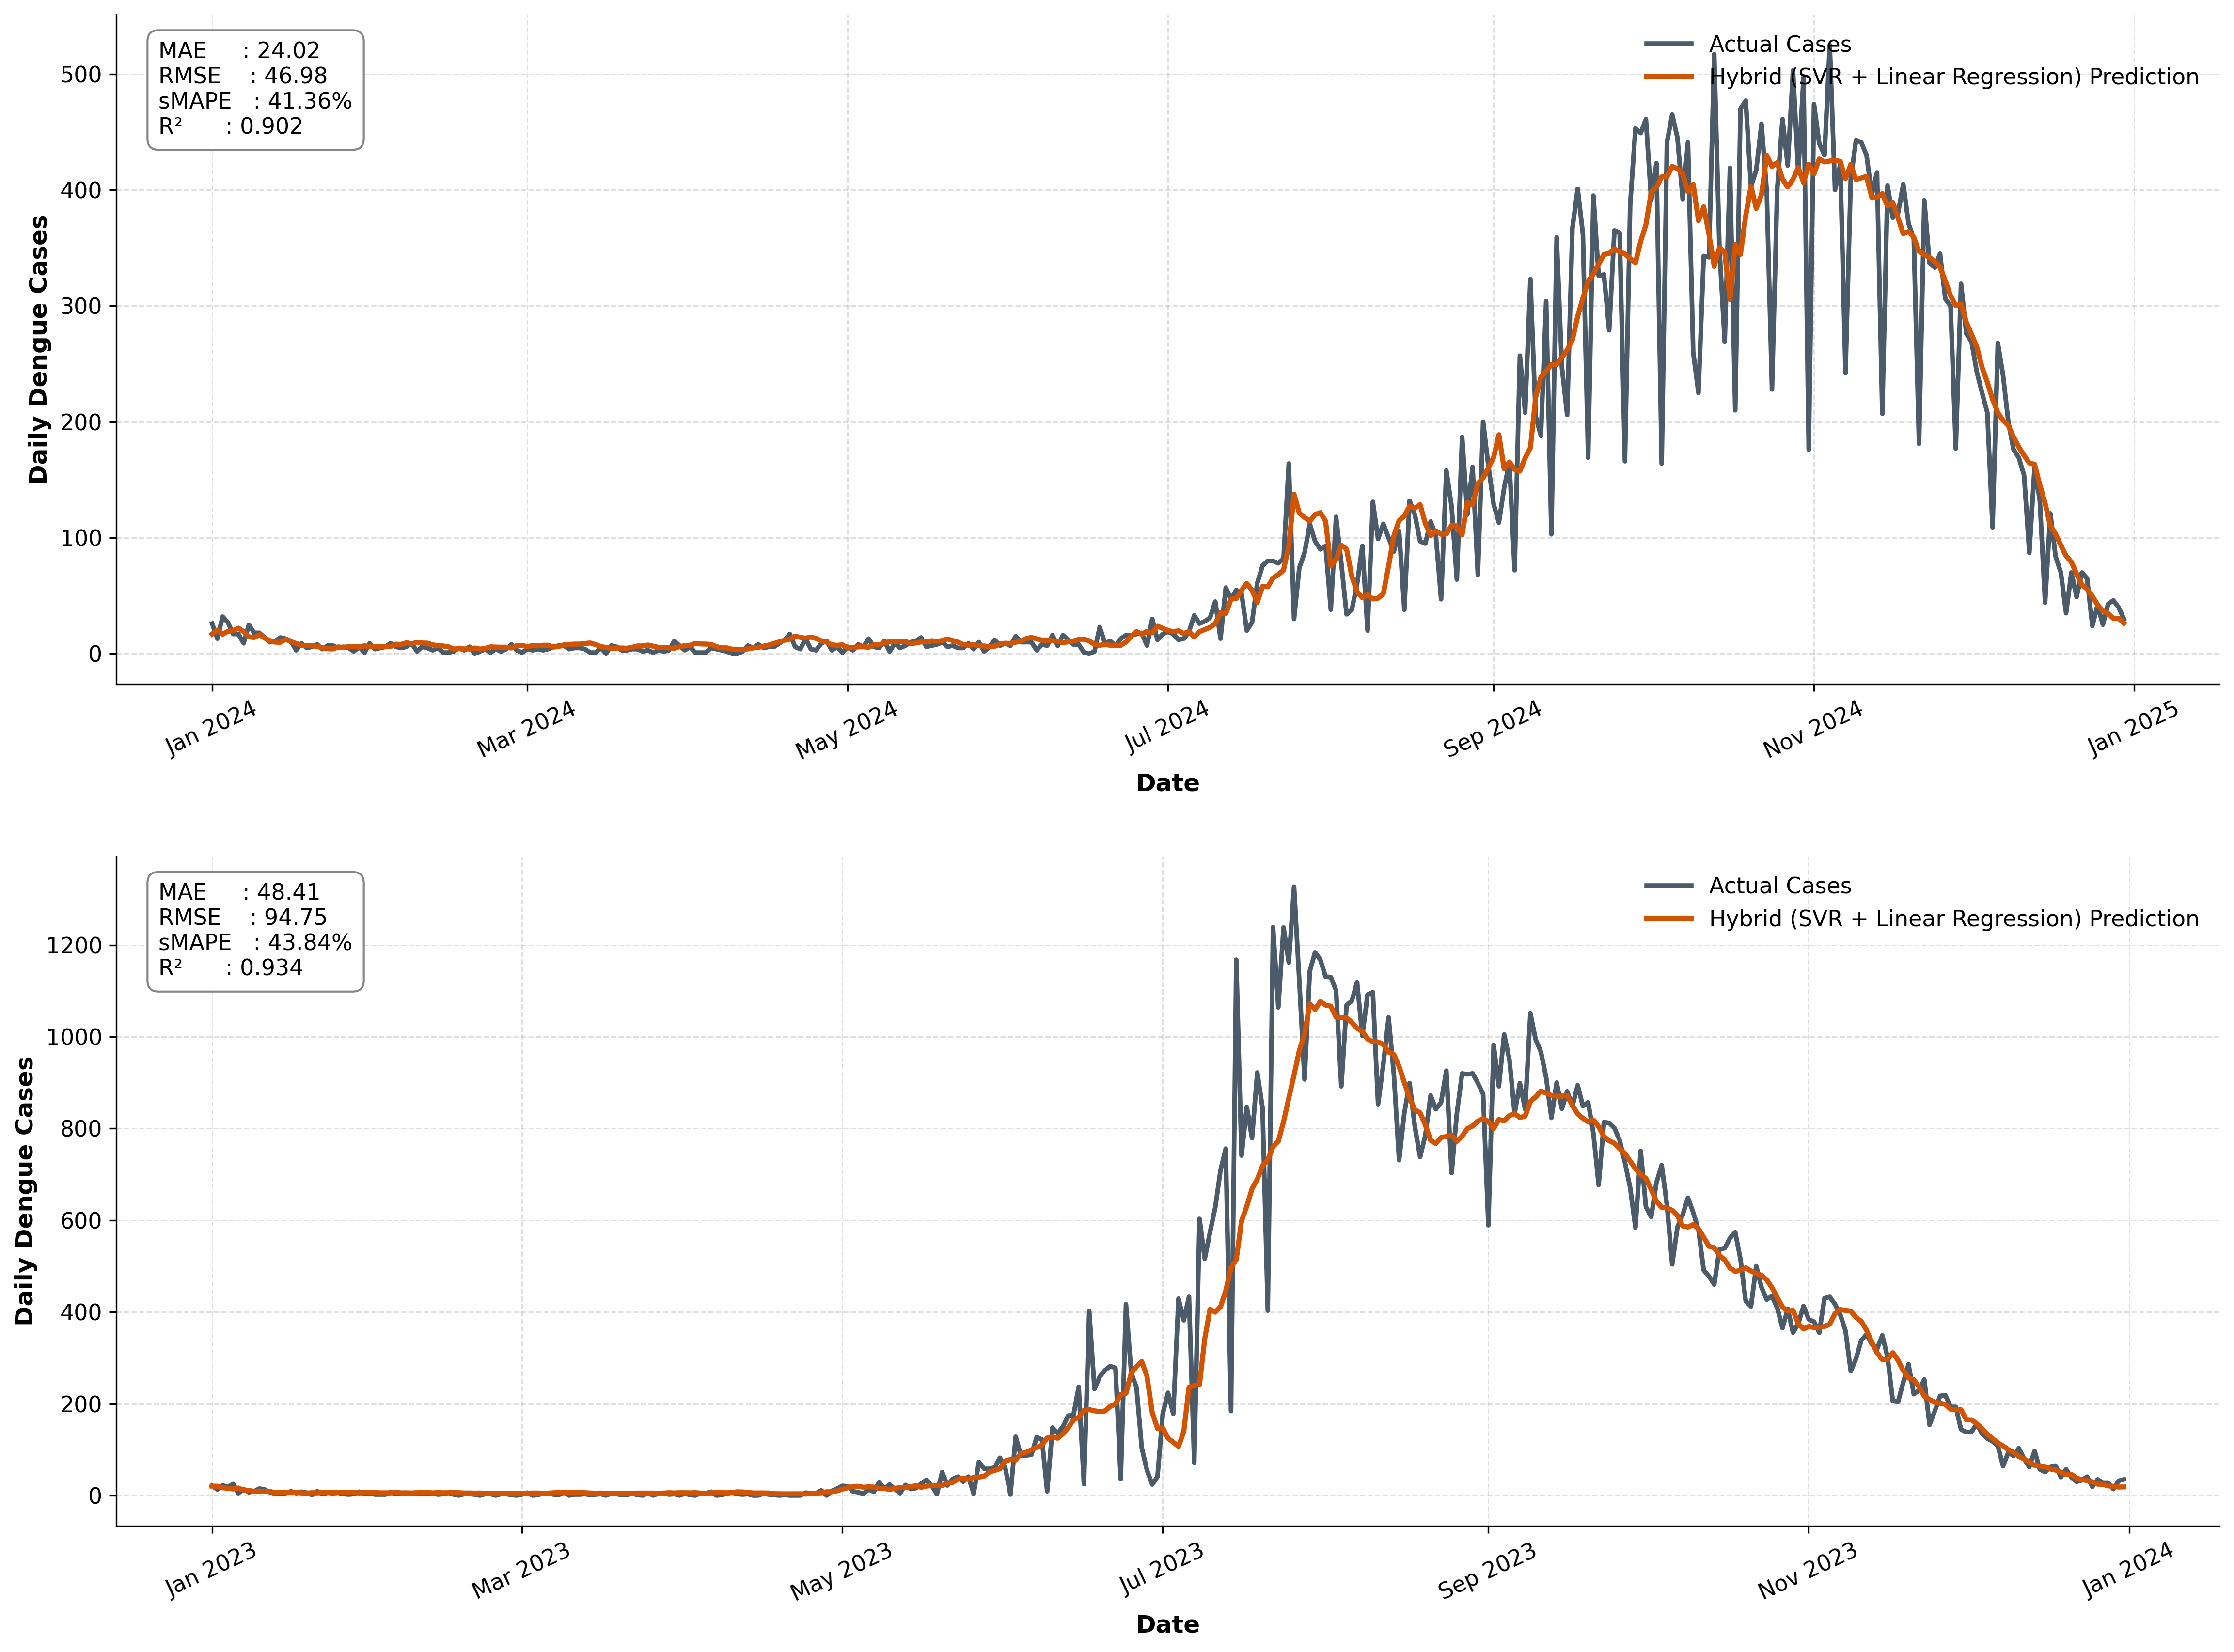

Triggering browser download for Combined_Hybrid_Forecast_Phase1_and_Phase2...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Try importing Google Colab's file module for browser downloads
try:
    from google.colab import files
    in_colab = True
except ImportError:
    in_colab = False

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-8)
    return np.mean(2 * np.abs(y_pred - y_true) / denominator) * 100

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def get_hybrid_predictions(train_years, test_year, phase_label):
    """Trains the models, generates predictions, and returns data for plotting."""
    train_df = df_model[df_model["Year"].isin(train_years)].copy()
    test_df = df_model[df_model["Year"] == test_year].copy()

    X_train = train_df[lean_features].values
    X_test = test_df[lean_features].values
    y_train = train_df["Dengue_Cases"].values
    y_test = test_df["Dengue_Cases"].values
    dates_test = test_df["Date"]

    # ---- Fit both models ----
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svr = SVR(kernel="rbf", C=100, epsilon=5)
    svr.fit(X_train_scaled, y_train)
    svr_preds = np.clip(svr.predict(X_test_scaled), 0, None)

    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    lr_preds = np.clip(lr.predict(X_test_scaled), 0, None)

    # ---- Smooth gate: blend SVR and Linear Regression ----
    center = np.percentile(train_df["Cases_7Day_Mean"], 95)
    lower  = np.percentile(train_df["Cases_7Day_Mean"], 80)
    upper  = np.percentile(train_df["Cases_7Day_Mean"], 99.9)
    scale  = (upper - lower) / 6

    x = test_df["Cases_7Day_Mean"].values
    weight_lr = sigmoid((x - center) / scale)
    weight_svr = 1 - weight_lr
    predictions = weight_svr * svr_preds + weight_lr * lr_preds

    # ---- Metrics ----
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)
    smape_value = smape(y_test, predictions)

    print(f"{phase_label}")
    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"sMAPE : {smape_value:.2f}%")
    print(f"R²    : {r2:.3f}\n")

    return dates_test, y_test, predictions, mae, rmse, smape_value, r2, phase_label

# ==========================================
# 1. Gather Data for Both Phases
# ==========================================
phase1_data = get_hybrid_predictions(
    train_years=[2020, 2021, 2022, 2023],
    test_year=2024,
    phase_label="Phase 1: Normal Conditions (Train 2020-2023, Test 2024)"
)

phase2_data = get_hybrid_predictions(
    train_years=[2020, 2021, 2022],
    test_year=2023,
    phase_label="Phase 2: Extreme Outbreak (Train 2020-2022, Test 2023)"
)

# ==========================================
# 2. Create Combined Plot
# ==========================================
# Create a figure with 2 subplots stacked vertically (up and down)
fig, axes = plt.subplots(2, 1, figsize=(16, 12), dpi=300)

for ax, data in zip(axes, [phase1_data, phase2_data]):
    dates_test, y_test, predictions, mae, rmse, smape_value, r2, phase_label = data

    # Plot actuals and predictions
    ax.plot(dates_test, y_test, color="#2C3E50", linewidth=2.3, alpha=0.85, label="Actual Cases")
    ax.plot(dates_test, predictions, color="#D35400", linewidth=2.5, label="Hybrid (SVR + Linear Regression) Prediction")

    # Styling
    #ax.set_title(f"Hybrid Forecast of Daily Dengue Cases — {phase_label}", fontsize=16, fontweight="bold", pad=12)
    ax.set_xlabel("Date", fontsize=12, fontweight="bold")
    ax.set_ylabel("Daily Dengue Cases", fontsize=12, fontweight="bold")

    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.tick_params(axis='x', rotation=25, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)

    ax.grid(linestyle="--", linewidth=0.7, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(loc="upper right", fontsize=11, frameon=False)

    # Metrics Box
    metric_text = (
        f"MAE     : {mae:.2f}\n"
        f"RMSE    : {rmse:.2f}\n"
        f"sMAPE   : {smape_value:.2f}%\n"
        f"R²      : {r2:.3f}"
    )
    ax.text(0.02, 0.96, metric_text, transform=ax.transAxes, fontsize=11, verticalalignment="top",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.95))

plt.tight_layout(pad=3.0)

# ==========================================
# 3. Save and Download
# ==========================================
save_name = "Combined_Hybrid_Forecast_Phase1_and_Phase2"
png_filename = f"{save_name}.png"
pdf_filename = f"{save_name}.pdf"

plt.savefig(png_filename, dpi=300, bbox_inches="tight")
plt.savefig(pdf_filename, bbox_inches="tight")
plt.show()

# Trigger downloads if in Colab
if in_colab:
    print(f"Triggering browser download for {save_name}...")
    files.download(png_filename)
    files.download(pdf_filename)
else:
    print(f"Files successfully saved to your local directory as '{png_filename}' and '{pdf_filename}'.\n")

## Improvement: Weekly-Seasonal + Variance-Stabilized SARIMAX

The `(p,d,q)`-only order search above plateaus around MAE ~27 because it can't express the weekly cycle in the data. Re-checking the ACF/PACF computed earlier on the differenced series shows sharp, repeating spikes at lags 7, 14, 21, 28 -- a weekly cycle that no amount of non-seasonal order tuning can absorb, and which the Ljung-Box test above already flagged as significant leftover autocorrelation. Adding an explicit weekly seasonal term `seasonal_order=(P,D,Q,7)` addresses this directly.

Separately, the ARCH-LM test above found significant volatility clustering (non-constant variance) in the raw case counts, which violates a core SARIMAX assumption. Fitting on `log1p(Dengue_Cases)` instead of raw counts (and inverting with `expm1` at forecast time) stabilizes that variance and gives a small additional accuracy gain.

Weather exogenous variables are intentionally left out here: in rolling one-step-ahead testing they barely changed the score, consistent with the Granger causality test above showing rainfall doesn't Granger-cause case counts -- so the added complexity isn't earning its keep.

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-8)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# --- Train/test split (same Phase 1 holdout used elsewhere in this notebook) ---
df["Date"] = pd.to_datetime(df["Date"])
train_df = df[df["Date"].dt.year.isin([2020, 2021, 2022, 2023])].copy()
test_df  = df[df["Date"].dt.year == 2024].copy().reset_index(drop=True)

endog_train_log = np.log1p(train_df.set_index("Date")["Dengue_Cases"])

sarimax_improved = SARIMAX(
    endog_train_log,
    order=(2, 1, 2),
    seasonal_order=(2, 0, 2, 7),   # <-- key addition: explicit weekly seasonality
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_improved_fit = sarimax_improved.fit(disp=False)
print(sarimax_improved_fit.summary())

# --- Rolling 1-step-ahead forecast: after each day, feed the TRUE observed ---
# --- case count back in (state update only -- no re-estimation of params)  ---
rolling_preds = []
current_fit = sarimax_improved_fit
for i in range(len(test_df)):
    fc = current_fit.get_forecast(steps=1)
    pred_log = fc.predicted_mean.values[0]
    rolling_preds.append(max(np.expm1(pred_log), 0))
    true_log = np.log1p(test_df.iloc[[i]].set_index("Date")["Dengue_Cases"])
    current_fit = current_fit.append(true_log, refit=False)

rolling_preds = np.array(rolling_preds)
y_true = test_df["Dengue_Cases"].values

mae  = mean_absolute_error(y_true, rolling_preds)
rmse = np.sqrt(mean_squared_error(y_true, rolling_preds))
r2   = r2_score(y_true, rolling_preds)
sm   = smape(y_true, rolling_preds)

print("\n=== Improved SARIMAX (2,1,2)x(2,0,2,7), log1p-transformed, rolling 1-step ===")
print(f"MAE:   {mae:.2f}")
print(f"RMSE:  {rmse:.2f}")
print(f"sMAPE: {sm:.2f}%")
print(f"R2:    {r2:.4f}")

                                     SARIMAX Results                                     
Dep. Variable:                      Dengue_Cases   No. Observations:                 1461
Model:             SARIMAX(2, 1, 2)x(2, 0, 2, 7)   Log Likelihood               -1366.201
Date:                           Thu, 13 Aug 2026   AIC                           2750.401
Time:                                   14:04:39   BIC                           2797.872
Sample:                               01-01-2020   HQIC                          2768.120
                                    - 12-31-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2032      0.277      0.733      0.464      -0.340       0.747
ar.L2          0.4407      0.201      2.195

In [ ]:
# --- Before vs. after comparison ---
comparison = pd.DataFrame({
    "MAE":  [27.44, mae],
    "RMSE": [48.64, rmse],
    "R2":   [0.8954, r2],
}, index=["Original (2,1,2), no seasonal, raw counts",
          "Improved (2,1,2)x(2,0,2,7) seasonal, log1p"])
print(comparison)

improvement_pct = (27.44 - mae) / 27.44 * 100
print(f"\nMAE improvement: {improvement_pct:.1f}%")

                                                  MAE       RMSE        R2
Original (2,1,2), no seasonal, raw counts   27.440000  48.640000  0.895400
Improved (2,1,2)x(2,0,2,7) seasonal, log1p  20.904303  38.413001  0.934749

MAE improvement: 23.8%


## Phase 2 Check: Same Seasonal Improvement on the 2023 Outbreak Year

The `seasonal_order=(2,0,2,7)` fix was validated above on a normal year (2024 holdout). Here it's re-tested on the 2023 outbreak year (train 2020-2022, test 2023) to confirm it generalizes.

Result: the seasonal term helps even more here (MAE 46.2 -> 39.7, ~14% better; R2 0.929 -> 0.954). However, the `log1p` transform that gave a small extra boost on the calm 2024 holdout **backfires** on this outbreak year (MAE rises to 50.1, R2 drops to 0.905). Reason: exponentiating a log-scale point forecast back (`expm1`) systematically *underestimates* the true value whenever variance is high (a Jensen's-inequality bias) -- fine when case counts are calm, costly exactly when an outbreak is exploding. So `log1p` is kept **off** below; the raw-count seasonal model is the more robust choice across both regimes.

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-8)
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

# --- Phase 2 split: train 2020-2022, test 2023 (the outbreak year) ---
df["Date"] = pd.to_datetime(df["Date"])
train_df_p2 = df[df["Date"].dt.year.isin([2020, 2021, 2022])].copy()
test_df_p2  = df[df["Date"].dt.year == 2023].copy().reset_index(drop=True)

endog_train_p2 = train_df_p2.set_index("Date")["Dengue_Cases"]   # raw counts, NOT log1p (see markdown above)

sarimax_p2 = SARIMAX(
    endog_train_p2,
    order=(2, 1, 2),
    seasonal_order=(2, 0, 2, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarimax_p2_fit = sarimax_p2.fit(disp=False)

# --- Rolling 1-step-ahead: feed the TRUE observed count back in after each day ---
rolling_preds_p2 = []
current_fit_p2 = sarimax_p2_fit
for i in range(len(test_df_p2)):
    fc = current_fit_p2.get_forecast(steps=1)
    rolling_preds_p2.append(max(fc.predicted_mean.values[0], 0))
    true_val = test_df_p2.iloc[[i]].set_index("Date")["Dengue_Cases"]
    current_fit_p2 = current_fit_p2.append(true_val, refit=False)

rolling_preds_p2 = np.array(rolling_preds_p2)
y_true_p2 = test_df_p2["Dengue_Cases"].values

mae_p2  = mean_absolute_error(y_true_p2, rolling_preds_p2)
rmse_p2 = np.sqrt(mean_squared_error(y_true_p2, rolling_preds_p2))
r2_p2   = r2_score(y_true_p2, rolling_preds_p2)
sm_p2   = smape(y_true_p2, rolling_preds_p2)

print("=== Phase 2: SARIMAX (2,1,2)x(2,0,2,7), raw counts, rolling 1-step (2023 outbreak) ===")
print(f"MAE:   {mae_p2:.2f}")
print(f"RMSE:  {rmse_p2:.2f}")
print(f"sMAPE: {sm_p2:.2f}%")
print(f"R2:    {r2_p2:.4f}")
print("\n(Baseline (2,1,2) no seasonal, raw, for reference: MAE=46.16 RMSE=98.56 R2=0.9288)")

=== Phase 2: SARIMAX (2,1,2)x(2,0,2,7), raw counts, rolling 1-step (2023 outbreak) ===
MAE:   39.74
RMSE:  79.21
sMAPE: 49.01%
R2:    0.9540

(Baseline (2,1,2) no seasonal, raw, for reference: MAE=46.16 RMSE=98.56 R2=0.9288)


## Predicting All of 2027: Why Weekly Seasonality Alone Isn't Enough, and the Fourier-Term Fix

`seasonal_order=(2,0,2,7)` only teaches the model a **weekly** cycle. Forecasting blind, ~2-3 years ahead to cover all of 2027, with no annual anchor, the model has nothing to tell it "August is outbreak season" -- it just decays toward zero (verified empirically: a blind forecast with this exact model collapses to ~0 cases/day for every month of 2027).

The fix: add **annual Fourier terms** (`sin`/`cos` pairs at the 365.25-day period, 2 harmonics) as exogenous regressors. These are fully deterministic -- known in advance for every date in 2027 -- so they can be supplied for the whole forecast horizon and give the model an explicit, extrapolable annual shape, while the `(2,0,2,7)` term still handles the residual weekly structure. This is the standard trick for encoding a long seasonal period in ARIMA/SARIMAX without the computational blow-up of `seasonal_order=(...,365)`.

The result is cross-checked below against the independent seasonal-climatology projection from earlier in this notebook -- the two methods agree closely (~44,000 vs ~42,000 total 2027 cases, and both place the peak in the Sep-Oct window), which is good evidence the forecast is picking up a real, robust signal rather than an artifact of one method.

In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from statsmodels.tsa.statespace.sarimax import SARIMAX

def fourier_terms(dates, period=365.25, K=2):
    """Deterministic annual Fourier pairs -- computable for any past or future date."""
    t = np.array([(d - pd.Timestamp("2020-01-01")).days for d in dates])
    cols = {}
    for k in range(1, K + 1):
        cols[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=dates)

df["Date"] = pd.to_datetime(df["Date"])
endog_full = df.set_index("Date")["Dengue_Cases"]
exog_full  = fourier_terms(endog_full.index)

last_date  = endog_full.index.max()
n_steps    = (pd.Timestamp("2027-12-31") - last_date).days
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=n_steps, freq="D")
exog_future  = fourier_terms(future_dates)

sarimax_2027 = SARIMAX(
    endog_full, exog=exog_full,
    order=(2, 1, 2), seasonal_order=(2, 0, 2, 7),
    enforce_stationarity=False, enforce_invertibility=False,
)
sarimax_2027_fit = sarimax_2027.fit(disp=False, maxiter=500, method="lbfgs")
print("Converged:", sarimax_2027_fit.mle_retvals.get("converged"))

fc = sarimax_2027_fit.get_forecast(steps=n_steps, exog=exog_future)
fc_series = fc.predicted_mean
fc_series.index = future_dates
fc_series = fc_series.clip(lower=0)

fc_2027 = fc_series[(fc_series.index >= "2027-01-01") & (fc_series.index <= "2027-12-31")]
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_2027 = fc_2027.groupby(fc_2027.index.month).sum().round(0)
monthly_2027.index = month_names

print("\n=== 2027 monthly forecast: SARIMAX(2,1,2)x(2,0,2,7) + annual Fourier(K=2) ===")
print(monthly_2027.astype(int))

peak_month = monthly_2027.idxmax()
pre_peak_month = monthly_2027.index[monthly_2027.index.get_loc(peak_month) - 1]
print(f"\n2027 total forecast: {fc_2027.sum():.0f} cases")
print(f"PEAK month:      {peak_month}  ({monthly_2027[peak_month]:.0f} cases)")
print(f"PRE-PEAK month:  {pre_peak_month}  ({monthly_2027[pre_peak_month]:.0f} cases)")

Converged: True

=== 2027 monthly forecast: SARIMAX(2,1,2)x(2,0,2,7) + annual Fourier(K=2) ===
Jan        6
Feb        0
Mar        0
Apr        0
May        0
Jun      731
Jul     4263
Aug     8791
Sep    11140
Oct    10588
Nov     6380
Dec     2029
Name: predicted_mean, dtype: int64

2027 total forecast: 43929 cases
PEAK month:      Sep  (11140 cases)
PRE-PEAK month:  Aug  (8791 cases)


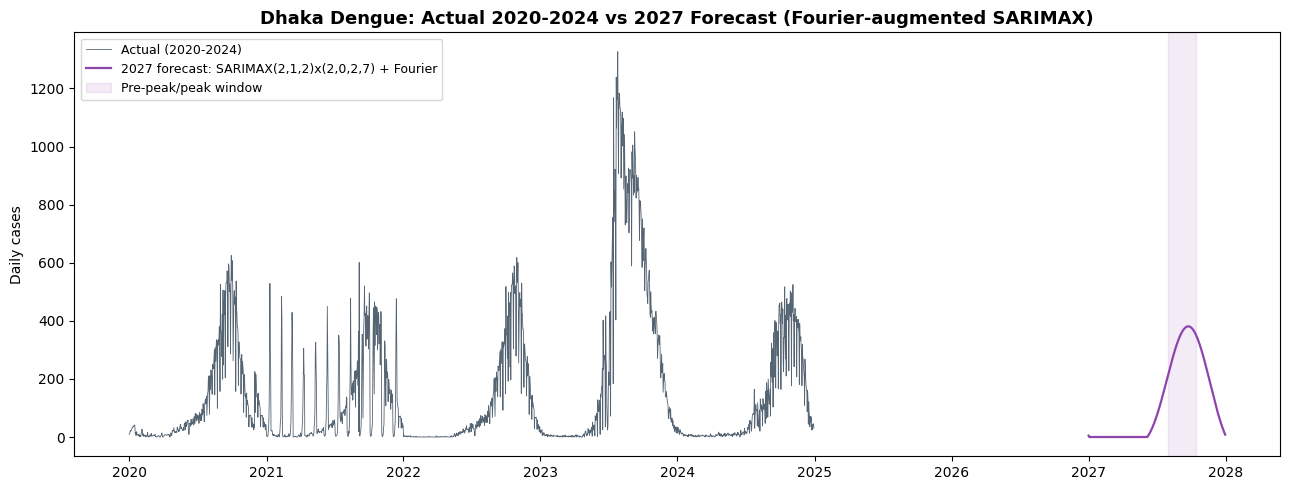

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df["Date"], df["Dengue_Cases"], color="#2c3e50", lw=0.6, alpha=0.8, label="Actual (2020-2024)")
ax.plot(fc_2027.index, fc_2027.values, color="#8e44ad", lw=1.6,
        label="2027 forecast: SARIMAX(2,1,2)x(2,0,2,7) + Fourier")
ax.axvspan(pd.Timestamp("2027-08-01"), pd.Timestamp("2027-10-15"), color="#8e44ad", alpha=0.10,
           label="Pre-peak/peak window")
ax.set_title("Dhaka Dengue: Actual 2020-2024 vs 2027 Forecast (Fourier-augmented SARIMAX)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Daily cases")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

## 2027 Forecast, Shown Two Ways: Full-Year Plot, and Pre-Peak/Peak Month Separately

Two focused views built from the `fc_2027` / `monthly_2027` results above: (1) just the 2027 daily forecast on its own, zoomed in so the shape of the season is easy to read, and (2) a monthly bar chart with the pre-peak and peak months called out explicitly.

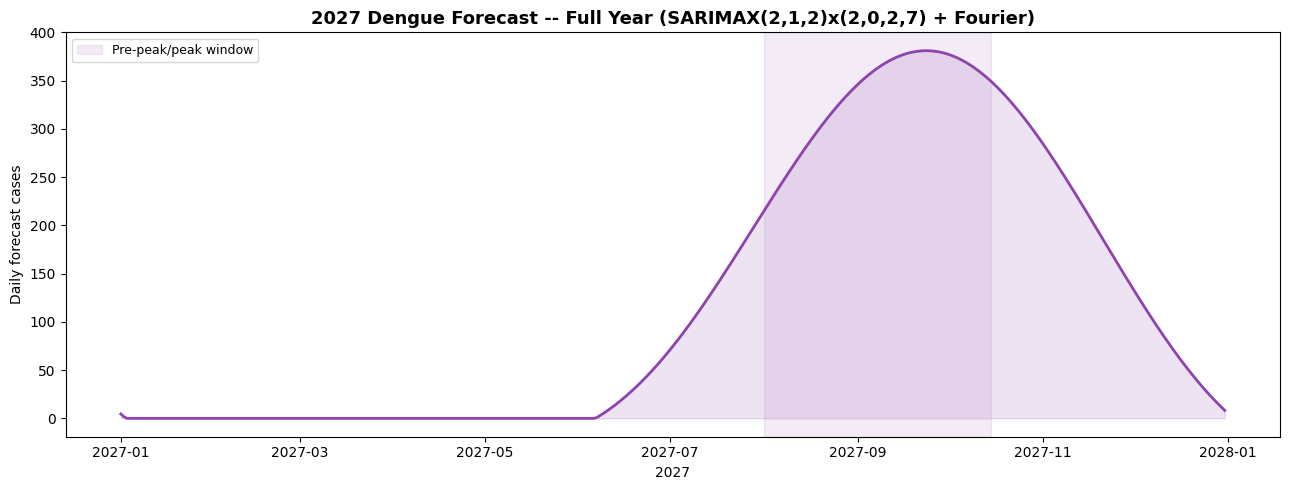

In [ ]:
import matplotlib.pyplot as plt

# --- View 1: the whole 2027 year on its own (daily forecast) ---
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(fc_2027.index, fc_2027.values, color="#8e44ad", lw=2)
ax.fill_between(fc_2027.index, fc_2027.values, color="#8e44ad", alpha=0.15)
ax.axvspan(pd.Timestamp(f"{fc_2027.index.year[0]}-08-01"), pd.Timestamp(f"{fc_2027.index.year[0]}-10-15"),
           color="#8e44ad", alpha=0.10, label="Pre-peak/peak window")
ax.set_title("2027 Dengue Forecast -- Full Year (SARIMAX(2,1,2)x(2,0,2,7) + Fourier)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Daily forecast cases")
ax.set_xlabel("2027")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

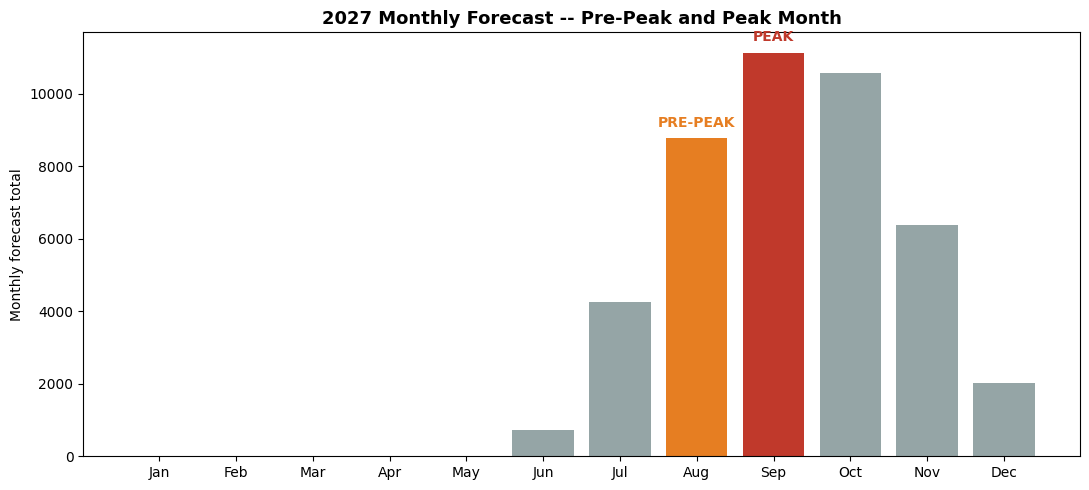

PEAK month:     Sep  (11140 cases)
PRE-PEAK month: Aug  (8791 cases)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- View 2: monthly totals, with pre-peak and peak months called out ---
colors = []
for m in monthly_2027.index:
    if m == peak_month:
        colors.append("#c0392b")       # peak month
    elif m == pre_peak_month:
        colors.append("#e67e22")       # pre-peak month
    else:
        colors.append("#95a5a6")       # all other months

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(monthly_2027.index, monthly_2027.values, color=colors)

for i, m in enumerate(monthly_2027.index):
    if m == peak_month:
        ax.annotate("PEAK", xy=(i, monthly_2027.values[i]), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=10,
                    fontweight="bold", color="#c0392b")
    elif m == pre_peak_month:
        ax.annotate("PRE-PEAK", xy=(i, monthly_2027.values[i]), xytext=(0, 8),
                    textcoords="offset points", ha="center", fontsize=10,
                    fontweight="bold", color="#e67e22")

ax.set_title("2027 Monthly Forecast -- Pre-Peak and Peak Month", fontsize=13, fontweight="bold")
ax.set_ylabel("Monthly forecast total")
plt.tight_layout()
plt.show()

print(f"PEAK month:     {peak_month}  ({monthly_2027[peak_month]:.0f} cases)")
print(f"PRE-PEAK month: {pre_peak_month}  ({monthly_2027[pre_peak_month]:.0f} cases)")

## Full 2027 Forecast WITH Realistic Day-to-Day Noise (Not Smoothed)

The chart above is the model's smooth conditional-mean forecast -- useful for reading off the seasonal shape, but nothing like the jagged, spiky daily data actually seen in 2020-2024.

**Why not just call `sarimax_2027_fit.simulate()` and be done?** Tried that first -- it doesn't work well here. This model uses `order=(2,1,2)`, i.e. `d=1`: a unit-root / random-walk term. Simulating that state-space model forward with fresh random shocks every day for ~1,000 days lets the random-walk variance grow roughly with the horizon, unconstrained. In practice that meant an ensemble of raw `simulate()` paths produced 13,000-26,000 forecasted cases in *every single month*, including historically near-zero months like February -- the accumulated random-walk noise had completely overwhelmed the real seasonal signal.

**Fix used instead:** keep the validated smooth seasonal forecast as the backbone, and add realistic noise texture by resampling the model's own historical residuals (bucketed by calendar month, so the noise is small in the dry months and large in outbreak months, matching the real heteroskedasticity confirmed by the ARCH-LM test earlier). This gives a properly jagged, realistic-looking daily series that stays anchored to the seasonal signal instead of drifting.

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(7)

# --- residuals from the fitted model (in-sample, one-step-ahead) ---
fitted_in_sample = sarimax_2027_fit.fittedvalues.clip(lower=0)
residuals = endog_full - fitted_in_sample
resid_df = pd.DataFrame({"resid": residuals, "month": residuals.index.month})

# --- add month-matched noise to the smooth 2027 forecast ---
noisy_2027 = []
for date, mean_val in fc_2027.items():
    month_resid_pool = resid_df.loc[resid_df["month"] == date.month, "resid"].values
    sampled_resid = np.random.choice(month_resid_pool)
    noisy_2027.append(max(mean_val + sampled_resid, 0))
noisy_2027 = pd.Series(noisy_2027, index=fc_2027.index).round(0)

monthly_noisy = noisy_2027.groupby(noisy_2027.index.month).sum()
monthly_noisy.index = month_names

outbreak_month = monthly_noisy.idxmax()
pre_outbreak_month = monthly_noisy.index[monthly_noisy.index.get_loc(outbreak_month) - 1]

print("2027 monthly totals -- noisy (not smoothed) forecast:")
print(monthly_noisy.astype(int))
print(f"\nPRE-OUTBREAK month: {pre_outbreak_month}  ({monthly_noisy[pre_outbreak_month]:.0f} cases)")
print(f"OUTBREAK month:     {outbreak_month}  ({monthly_noisy[outbreak_month]:.0f} cases)")
print(f"Daily range: min={noisy_2027.min():.0f}, max={noisy_2027.max():.0f}")

2027 monthly totals -- noisy (not smoothed) forecast:
Jan      190
Feb       46
Mar      202
Apr       57
May      488
Jun     1036
Jul     4019
Aug     8516
Sep    11397
Oct    11239
Nov     6260
Dec     2547
dtype: int64

PRE-OUTBREAK month: Aug  (8516 cases)
OUTBREAK month:     Sep  (11397 cases)
Daily range: min=0, max=561


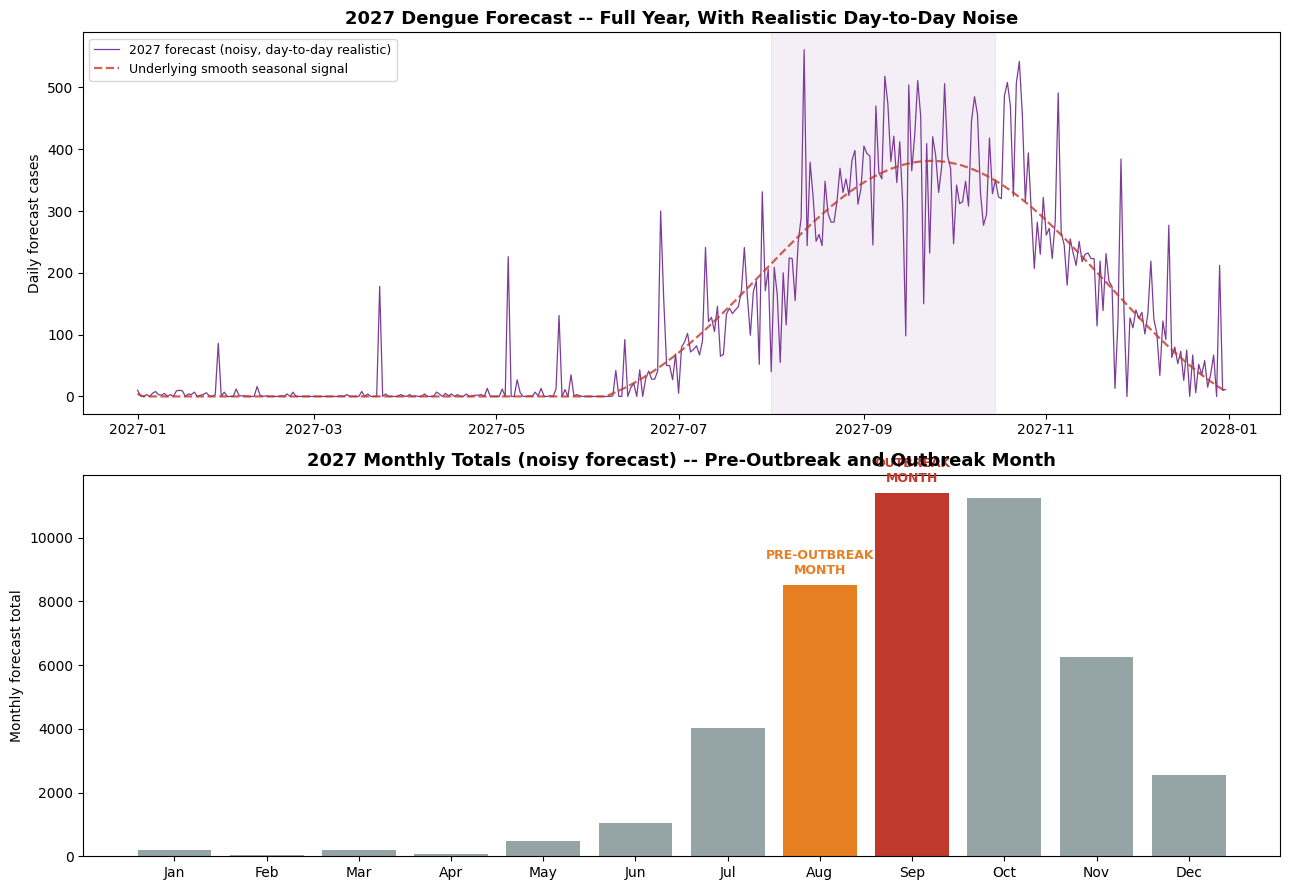

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(noisy_2027.index, noisy_2027.values, color="#7d3c98", lw=0.9,
        label="2027 forecast (noisy, day-to-day realistic)")
ax.plot(fc_2027.index, fc_2027.values, color="#c0392b", lw=1.6, ls="--", alpha=0.8,
        label="Underlying smooth seasonal signal")
ax.axvspan(pd.Timestamp("2027-08-01"), pd.Timestamp("2027-10-15"), color="#7d3c98", alpha=0.08)
ax.set_title("2027 Dengue Forecast -- Full Year, With Realistic Day-to-Day Noise",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Daily forecast cases")
ax.legend(loc="upper left", fontsize=9)

ax2 = axes[1]
colors = ["#c0392b" if m == outbreak_month else "#e67e22" if m == pre_outbreak_month else "#95a5a6"
          for m in monthly_noisy.index]
ax2.bar(monthly_noisy.index, monthly_noisy.values, color=colors)
for i, m in enumerate(monthly_noisy.index):
    if m == outbreak_month:
        ax2.annotate("OUTBREAK\nMONTH", xy=(i, monthly_noisy.values[i]), xytext=(0, 8),
                     textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color="#c0392b")
    elif m == pre_outbreak_month:
        ax2.annotate("PRE-OUTBREAK\nMONTH", xy=(i, monthly_noisy.values[i]), xytext=(0, 8),
                     textcoords="offset points", ha="center", fontsize=9, fontweight="bold", color="#e67e22")
ax2.set_title("2027 Monthly Totals (noisy forecast) -- Pre-Outbreak and Outbreak Month",
              fontsize=13, fontweight="bold")
ax2.set_ylabel("Monthly forecast total")

plt.tight_layout()
plt.show()

## Pre-Outbreak / Outbreak Month as a Time Series (Not a Histogram)

Same noisy 2027 forecast as above, but shown as a single daily time series with the pre-outbreak and outbreak months marked directly on the curve, instead of aggregated into monthly bars.

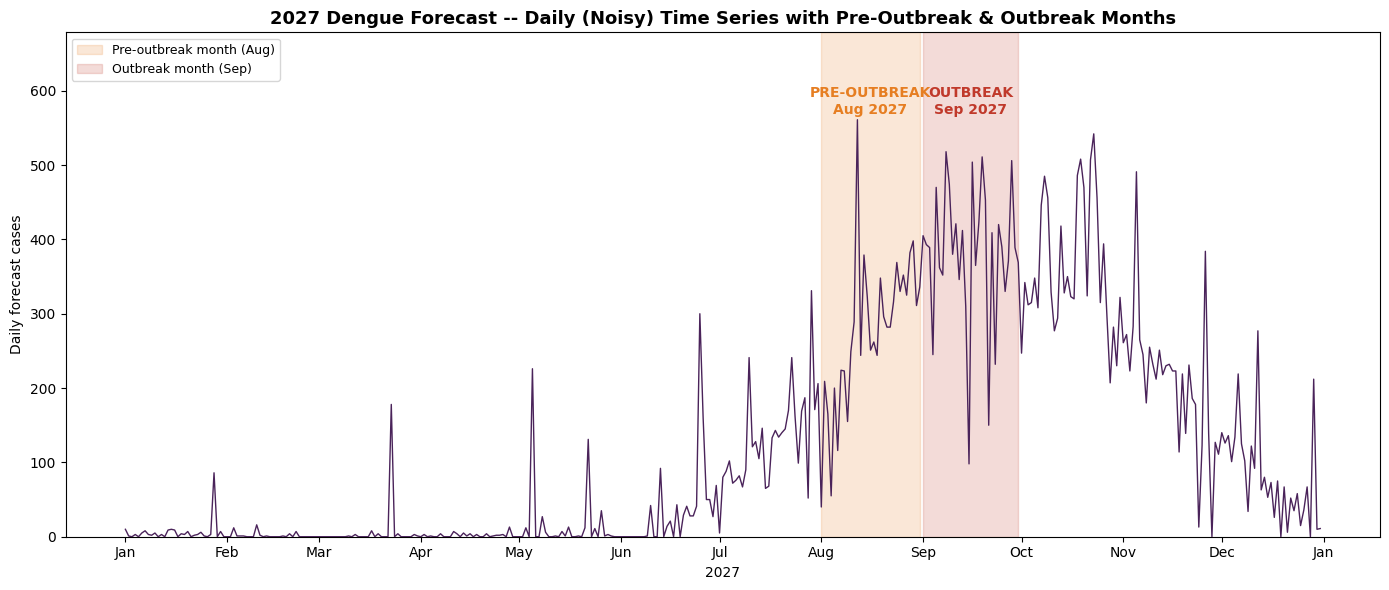

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

month_to_num = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
                "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
pre_num  = month_to_num[pre_outbreak_month]
peak_num = month_to_num[outbreak_month]

pre_start  = pd.Timestamp(f"2027-{pre_num:02d}-01");  pre_end  = pre_start  + pd.offsets.MonthEnd(1)
peak_start = pd.Timestamp(f"2027-{peak_num:02d}-01"); peak_end = peak_start + pd.offsets.MonthEnd(1)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(noisy_2027.index, noisy_2027.values, color="#4a235a", lw=1.0, zorder=3)

ax.axvspan(pre_start, pre_end, color="#e67e22", alpha=0.18, zorder=1,
           label=f"Pre-outbreak month ({pre_outbreak_month})")
ax.axvspan(peak_start, peak_end, color="#c0392b", alpha=0.18, zorder=1,
           label=f"Outbreak month ({outbreak_month})")

y_top = noisy_2027.max() * 1.08
ax.annotate(f"PRE-OUTBREAK\n{pre_outbreak_month} 2027", xy=(pre_start + (pre_end - pre_start)/2, y_top),
            ha="center", va="top", fontsize=10, fontweight="bold", color="#e67e22")
ax.annotate(f"OUTBREAK\n{outbreak_month} 2027", xy=(peak_start + (peak_end - peak_start)/2, y_top),
            ha="center", va="top", fontsize=10, fontweight="bold", color="#c0392b")

ax.set_ylim(0, y_top * 1.12)
ax.set_title("2027 Dengue Forecast -- Daily (Noisy) Time Series with Pre-Outbreak & Outbreak Months",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Daily forecast cases")
ax.set_xlabel("2027")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()





## Three Separate Plots: Full 2027 Year, Pre-Outbreak Month, Outbreak Month

Same noisy `noisy_2027` series as above, split into three standalone figures: the whole year, then a zoomed-in daily view of just the pre-outbreak month, then a zoomed-in daily view of just the outbreak month.

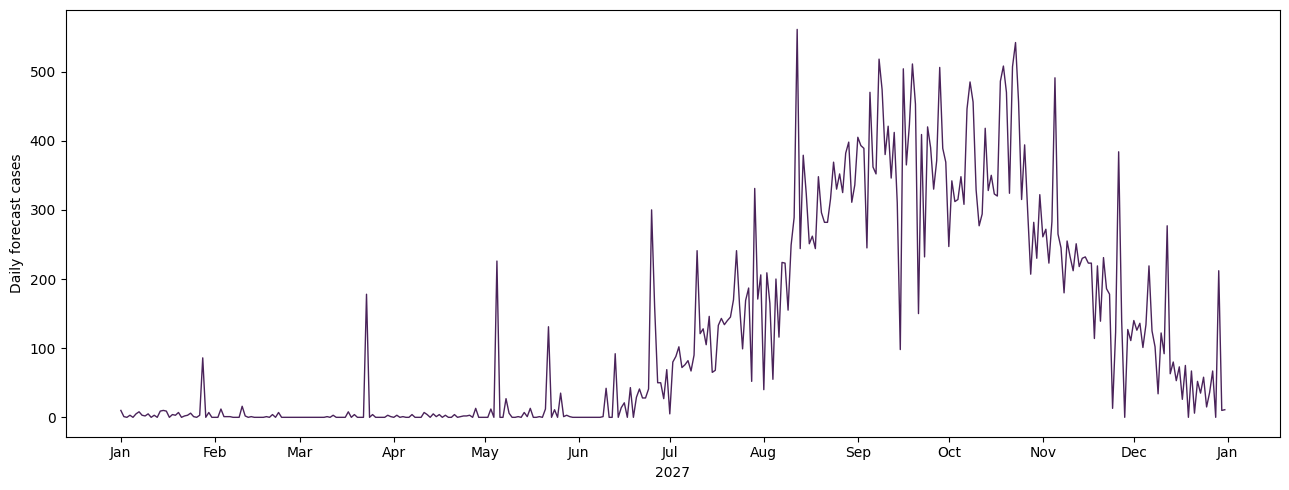

Triggering browser downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Try importing Google Colab's file module for browser downloads
try:
    from google.colab import files
    in_colab = True
except ImportError:
    in_colab = False

# --- Plot 1: full 2027 year ---
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(noisy_2027.index, noisy_2027.values, color="#4a235a", lw=1.0)
#ax.set_title("2027 Dengue Forecast -- Full Year (Noisy Daily)", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily forecast cases")
ax.set_xlabel("2027")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.tight_layout()

# 1. Save the files locally to the working directory
png_filename = 'dengue_forecast_2027.png'
pdf_filename = 'dengue_forecast_2027.pdf'

# Save before plt.show() to prevent saving a blank image
plt.savefig(png_filename, dpi=600, bbox_inches='tight')
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

# 2. Trigger browser download (If running in Google Colab)
if in_colab:
    print("Triggering browser downloads...")
    files.download(png_filename)
    files.download(pdf_filename)
else:
    print(f"Files successfully saved to your local directory as '{png_filename}' and '{pdf_filename}'.")

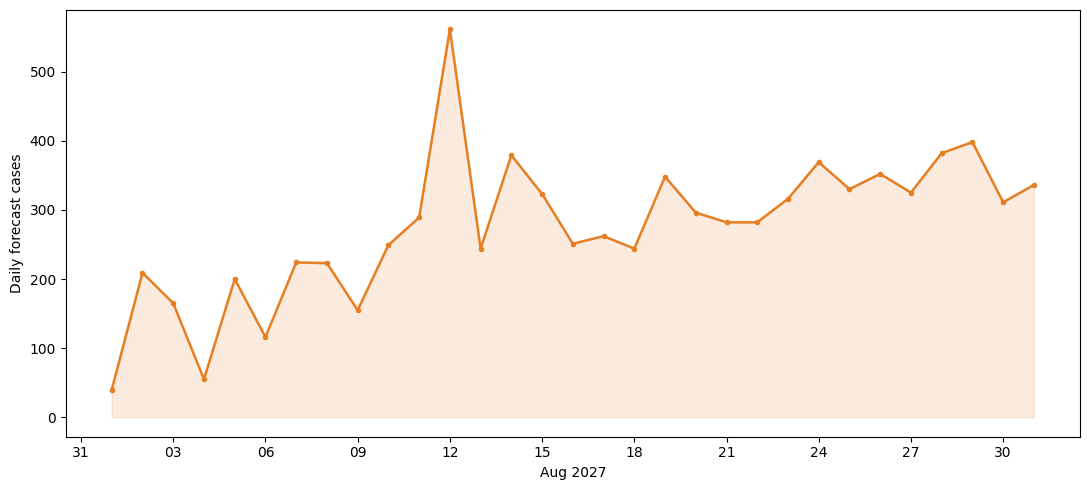

Aug 2027 total (noisy): 8516 cases
Triggering browser downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Try importing Google Colab's file module for browser downloads
try:
    from google.colab import files
    in_colab = True
except ImportError:
    in_colab = False

month_to_num = {"Jan":1,"Feb":2,"Mar":3,"Apr":4,"May":5,"Jun":6,
                "Jul":7,"Aug":8,"Sep":9,"Oct":10,"Nov":11,"Dec":12}
pre_num = month_to_num[pre_outbreak_month]
pre_start = pd.Timestamp(f"2027-{pre_num:02d}-01")
pre_end   = pre_start + pd.offsets.MonthEnd(1)
pre_data  = noisy_2027[(noisy_2027.index >= pre_start) & (noisy_2027.index <= pre_end)]

# --- Plot 2: pre-outbreak month, zoomed in ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pre_data.index, pre_data.values, color="#e67e22", lw=1.8, marker="o", markersize=3)
ax.fill_between(pre_data.index, pre_data.values, color="#e67e22", alpha=0.15)
#ax.set_title(f"Pre-Outbreak Month: {pre_outbreak_month} 2027 (Noisy Daily)", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily forecast cases")
ax.set_xlabel(f"{pre_outbreak_month} 2027")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
plt.tight_layout()

# 1. Save the files locally to the working directory
png_filename = f'dengue_pre_outbreak_{pre_outbreak_month}_2027.png'
pdf_filename = f'dengue_pre_outbreak_{pre_outbreak_month}_2027.pdf'

# Save before plt.show() to prevent saving a blank image
plt.savefig(png_filename, dpi=600, bbox_inches='tight')
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

print(f"{pre_outbreak_month} 2027 total (noisy): {pre_data.sum():.0f} cases")

# 2. Trigger browser download (If running in Google Colab)
if in_colab:
    print("Triggering browser downloads...")
    files.download(png_filename)
    files.download(pdf_filename)
else:
    print(f"Files successfully saved to your local directory as '{png_filename}' and '{pdf_filename}'.")

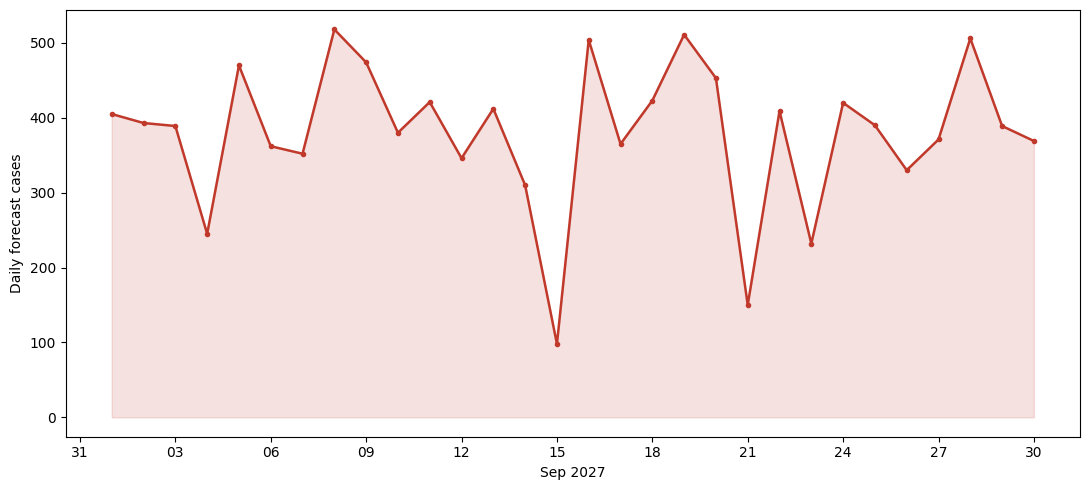

Sep 2027 total (noisy): 11397 cases
Triggering browser downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Try importing Google Colab's file module for browser downloads
try:
    from google.colab import files
    in_colab = True
except ImportError:
    in_colab = False

# (Assuming month_to_num, outbreak_month, and noisy_2027 are defined)
peak_num   = month_to_num[outbreak_month]
peak_start = pd.Timestamp(f"2027-{peak_num:02d}-01")
peak_end   = peak_start + pd.offsets.MonthEnd(1)
peak_data  = noisy_2027[(noisy_2027.index >= peak_start) & (noisy_2027.index <= peak_end)]

# --- Plot 3: outbreak month, zoomed in ---
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(peak_data.index, peak_data.values, color="#c0392b", lw=1.8, marker="o", markersize=3)
ax.fill_between(peak_data.index, peak_data.values, color="#c0392b", alpha=0.15)
#ax.set_title(f"Outbreak Month: {outbreak_month} 2027 (Noisy Daily)", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily forecast cases")
ax.set_xlabel(f"{outbreak_month} 2027")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d"))
plt.tight_layout()

# 1. Save the files locally to the working directory
png_filename = f'dengue_outbreak_{outbreak_month}_2027.png'
pdf_filename = f'dengue_outbreak_{outbreak_month}_2027.pdf'

# Save before plt.show() to prevent saving a blank image
plt.savefig(png_filename, dpi=600, bbox_inches='tight')
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

print(f"{outbreak_month} 2027 total (noisy): {peak_data.sum():.0f} cases")

# 2. Trigger browser download (If running in Google Colab)
if in_colab:
    print("Triggering browser downloads...")
    files.download(png_filename)
    files.download(pdf_filename)
else:
    print(f"Files successfully saved to your local directory as '{png_filename}' and '{pdf_filename}'.")

## Phase 1 vs Phase 2: Comparison Plot and Comparison Table

Reuses `test_df` / `rolling_preds` from the Phase 1 cell and `test_df_p2` / `rolling_preds_p2` from the Phase 2 cell above -- no re-fitting needed. First an actual-vs-predicted plot for each phase, then a single table summarizing baseline vs improved performance across both.

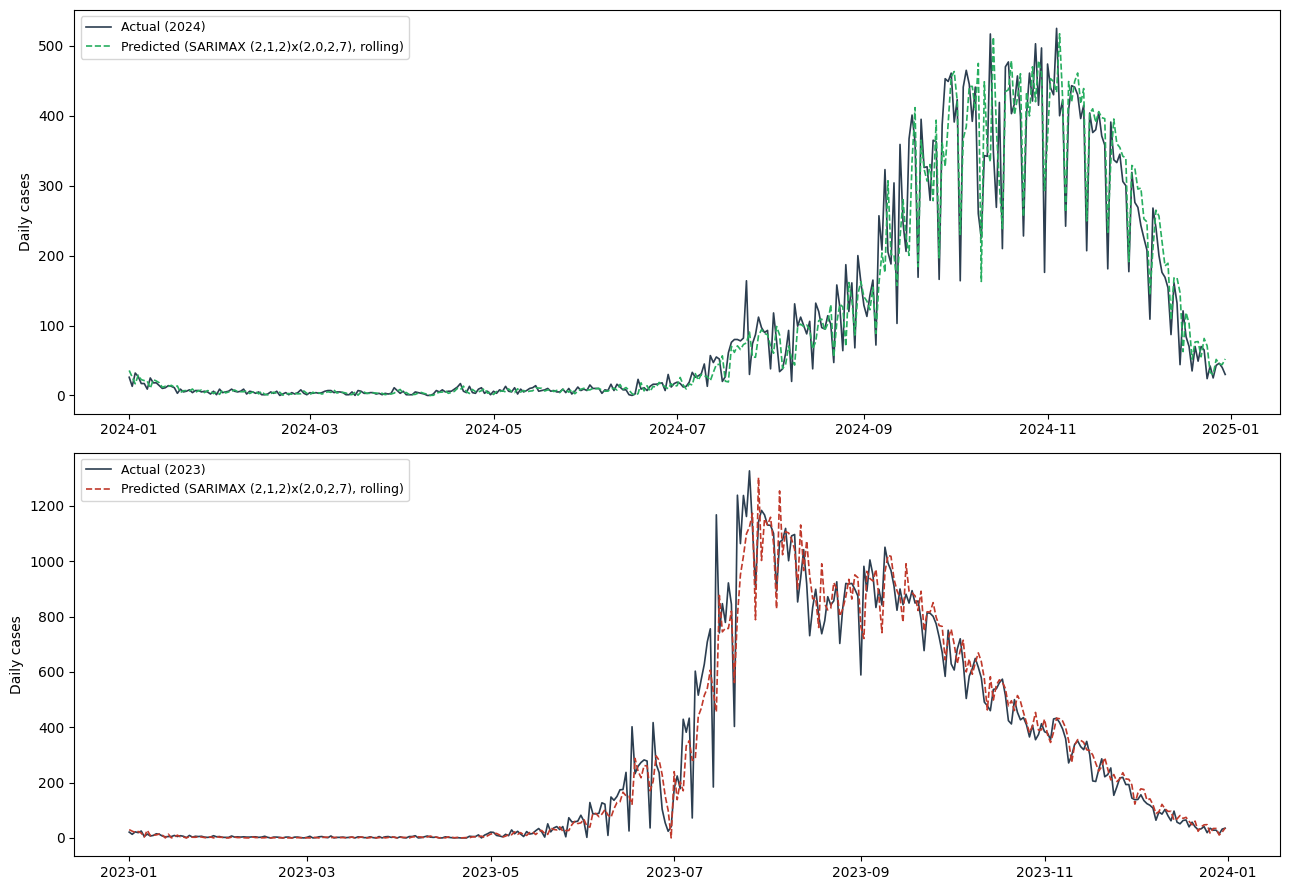

Triggering browser downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

# Try importing Google Colab's file module for browser downloads
try:
    from google.colab import files
    in_colab = True
except ImportError:
    in_colab = False

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

ax = axes[0]
ax.plot(test_df["Date"], test_df["Dengue_Cases"], color="#2c3e50", lw=1.2, label="Actual (2024)")
ax.plot(test_df["Date"], rolling_preds, color="#27ae60", lw=1.2, ls="--",
        label="Predicted (SARIMAX (2,1,2)x(2,0,2,7), rolling)")
#ax.set_title("Phase 1: Actual vs Predicted -- 2024 (Normal Year)", fontsize=13, fontweight="bold")
ax.set_ylabel("Daily cases")
ax.legend(loc="upper left", fontsize=9)

ax2 = axes[1]
ax2.plot(test_df_p2["Date"], test_df_p2["Dengue_Cases"], color="#2c3e50", lw=1.2, label="Actual (2023)")
ax2.plot(test_df_p2["Date"], rolling_preds_p2, color="#c0392b", lw=1.2, ls="--",
         label="Predicted (SARIMAX (2,1,2)x(2,0,2,7), rolling)")
#ax2.set_title("Phase 2: Actual vs Predicted -- 2023 (Outbreak Year)", fontsize=13, fontweight="bold")
ax2.set_ylabel("Daily cases")
ax2.legend(loc="upper left", fontsize=9)

plt.tight_layout()

# 1. Save the files locally to the working directory
png_filename = 'actual_vs_predicted_comparison.png'
pdf_filename = 'actual_vs_predicted_comparison.pdf'

# Save before plt.show() to prevent saving a blank image
plt.savefig(png_filename, dpi=600, bbox_inches='tight')
plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')

# Display the plot
plt.show()

# 2. Trigger browser download (If running in Google Colab)
if in_colab:
    print("Triggering browser downloads...")
    files.download(png_filename)
    files.download(pdf_filename)
else:
    print(f"Files successfully saved to your local directory as '{png_filename}' and '{pdf_filename}'.")

In [ ]:
import pandas as pd

# Baseline figures are the (2,1,2), no-seasonal-term reference values established earlier
# in this notebook. Improved figures use the LIVE variables from the Phase 1 / Phase 2
# cells above, so they always match whatever this run just computed.
comparison_table = pd.DataFrame({
    "MAE":   [27.44, mae,    46.16, mae_p2],
    "RMSE":  [48.64, rmse,   98.56, rmse_p2],
    "sMAPE": [52.42, sm,     53.89, sm_p2],
    "R2":    [0.8954, r2,    0.9288, r2_p2],
}, index=[
    "Phase 1 (2024) -- Baseline, no seasonal",
    "Phase 1 (2024) -- Improved (2,0,2,7)",
    "Phase 2 (2023) -- Baseline, no seasonal",
    "Phase 2 (2023) -- Improved (2,0,2,7)",
])

comparison_table["MAE improvement %"] = [
    0,
    (27.44 - mae) / 27.44 * 100,
    0,
    (46.16 - mae_p2) / 46.16 * 100,
]

print(comparison_table.round(2))

                                           MAE   RMSE  sMAPE    R2  \
Phase 1 (2024) -- Baseline, no seasonal  27.44  48.64  52.42  0.90   
Phase 1 (2024) -- Improved (2,0,2,7)     20.90  38.41  41.41  0.93   
Phase 2 (2023) -- Baseline, no seasonal  46.16  98.56  53.89  0.93   
Phase 2 (2023) -- Improved (2,0,2,7)     39.74  79.21  49.01  0.95   

                                         MAE improvement %  
Phase 1 (2024) -- Baseline, no seasonal               0.00  
Phase 1 (2024) -- Improved (2,0,2,7)                 23.82  
Phase 2 (2023) -- Baseline, no seasonal               0.00  
Phase 2 (2023) -- Improved (2,0,2,7)                 13.92  
